In [1]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
dgis = pd.read_csv("dgis_integrado.csv")
inegi = pd.read_csv("iter_interpolado.csv")
coneval = pd.read_csv("pobreza_municipal_clean_interpolado.csv")
coneval2 = coneval[coneval["año"] >= 2015]
coneval2
#coneval2 = pd.read_csv("/../pobreza_municipal_clean_interpolado.csv")

#df=dgis
#valores_unicos = df['ent_resid'].unique()
#print(valores_unicos)
#valores_unicos = df['clave_municipio'].unique()
#print(valores_unicos)
#valores_unicos = df['sexo'].unique()
#print(valores_unicos)
#valores_unicos = df['edad'].unique()
#print(valores_unicos)
#valores_unicos = df['edad_agru'].unique()
#print(valores_unicos)
#valores_unicos = df['año'].unique()
#print(valores_unicos)
#valores_unicos = dgis['escolarida'].unique()
#print(valores_unicos)



,año,clave_municipio,municipio,pobreza_porcentaje,pobreza_poblacion,pobreza_extrema_porcentaje,pobreza_extrema_poblacion,pobreza_moderada_porcentaje,pobreza_moderada_poblacion
5,2015,2.0,Azcapotzalco,19.50,77859.0,0.5,2132.0,18.90,75727.0
6,2016,2.0,Azcapotzalco,20.44,81876.0,0.9,3704.0,19.46,78172.0
7,2017,2.0,Azcapotzalco,21.38,85893.0,1.3,5275.0,20.02,80617.0
8,2018,2.0,Azcapotzalco,22.32,89909.0,1.7,6847.0,20.58,83063.0
9,2019,2.0,Azcapotzalco,23.26,93926.0,2.1,8418.0,21.14,85508.0
...,...,...,...,...,...,...,...,...,...
171,2016,10.0,Álvaro Obregón,29.86,221682.0,2.0,14610.0,27.86,207073.0
172,2017,10.0,Álvaro Obregón,31.82,234676.0,2.9,21197.0,28.92,213479.0
173,2018,10.0,Álvaro Obregón,33.78,247669.0,3.8,27784.0,29.98,219886.0
174,2019,10.0,Álvaro Obregón,35.74,260663.0,4.7,34371.0,31.04,226292.0


In [3]:
dgis["edad"].max()

113

In [4]:
print(dgis.columns)
print(inegi.columns)
print(coneval.columns)

Index(['ent_resid', 'clave_municipio', 'causa_def', 'sexo', 'edad',
       'edad_agru', 'dia_ocurr', 'mes_ocurr', 'año', 'escolarida'],
      dtype='object')
Index(['año', 'mun', 'nom_mun', 'pobtot', 'pobmas', 'pobfem', 'p15ym_an_m',
       'p15ym_an_f', 'p15ym_se', 'p15ym_se_m', 'p15ym_se_f', 'p15pri_in',
       'p15pri_inm', 'p15pri_inf', 'p15pri_co', 'p15pri_com', 'p15pri_cof',
       'p15sec_in', 'p15sec_inm', 'p15sec_inf', 'p15sec_co', 'p15sec_com',
       'p15sec_cof', 'p18ym_pb', 'p18ym_pb_m', 'p18ym_pb_f', 'p_0a14',
       'p_0a14_m', 'p_0a14_f', 'p_15a24', 'p_15a24_m', 'p_15a24_f', 'p_25a59',
       'p_25a59_m', 'p_25a59_f', 'p_60ymas', 'p_60ymas_m', 'p_60ymas_f',
       'p15ym_an'],
      dtype='object')
Index(['año', 'clave_municipio', 'municipio', 'pobreza_porcentaje',
       'pobreza_poblacion', 'pobreza_extrema_porcentaje',
       'pobreza_extrema_poblacion', 'pobreza_moderada_porcentaje',
       'pobreza_moderada_poblacion'],
      dtype='object')


In [5]:
dgis['clase_enf'] = dgis['causa_def'].str.extract(r'(\d+)').astype(int)

def clasificar_diabetes(codigo):
    if 100 <= codigo <= 109:
        return 1
    elif 110 <= codigo <= 119:
        return 2
    elif 120 <= codigo <= 149:
        return 3 #'otras diabetes'
    else:
        return 'Fuera de rango'

dgis['dmt'] = dgis['clase_enf'].apply(clasificar_diabetes)
dgis

,ent_resid,clave_municipio,causa_def,sexo,edad,edad_agru,dia_ocurr,mes_ocurr,año,escolarida,clase_enf,dmt
0,9,7,E117,2,68,18,21,4,2015,1,117,2
1,9,4,E119,2,72,19,12,11,2015,5,119,2
2,9,5,E149,2,88,22,10,7,2015,3,149,3
3,9,5,E116,1,87,22,22,7,2015,5,116,2
4,9,10,E112,1,57,16,5,7,2015,3,112,2
...,...,...,...,...,...,...,...,...,...,...,...,...
61142,9,12,E117,1,50,15,16,11,2020,4,117,2
61143,9,17,E147,2,73,19,12,11,2020,6,147,3
61144,9,17,E116,1,81,21,16,12,2020,3,116,2
61145,9,2,E142,1,60,17,20,8,2020,8,142,3


In [6]:
dgis = dgis[dgis['dmt'] <= 2]
dgis2 =dgis[['clave_municipio', 'sexo', 'edad', 'año', 'escolarida','dmt']]
dgis2 = dgis2.rename(columns={'año': 'periodo'})
dgis2 = dgis2.rename(columns={'escolarida': 'nivel_academico'})#este dataframe se usara para la base de datos
dgis2. to_csv("dgis_integrado2.csv", index=False, encoding="utf-8")

C:\Users\super\AppData\Local\Temp\ipykernel_20416\1294261911.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dgis['rango_edad'] = pd.cut(dgis['edad'], bins=bins, labels=labels, right=False)
C:\Users\super\AppData\Local\Temp\ipykernel_20416\1294261911.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agrupado = dgis.groupby(['año', 'rango_edad']).size().reset_index(name='conteo')


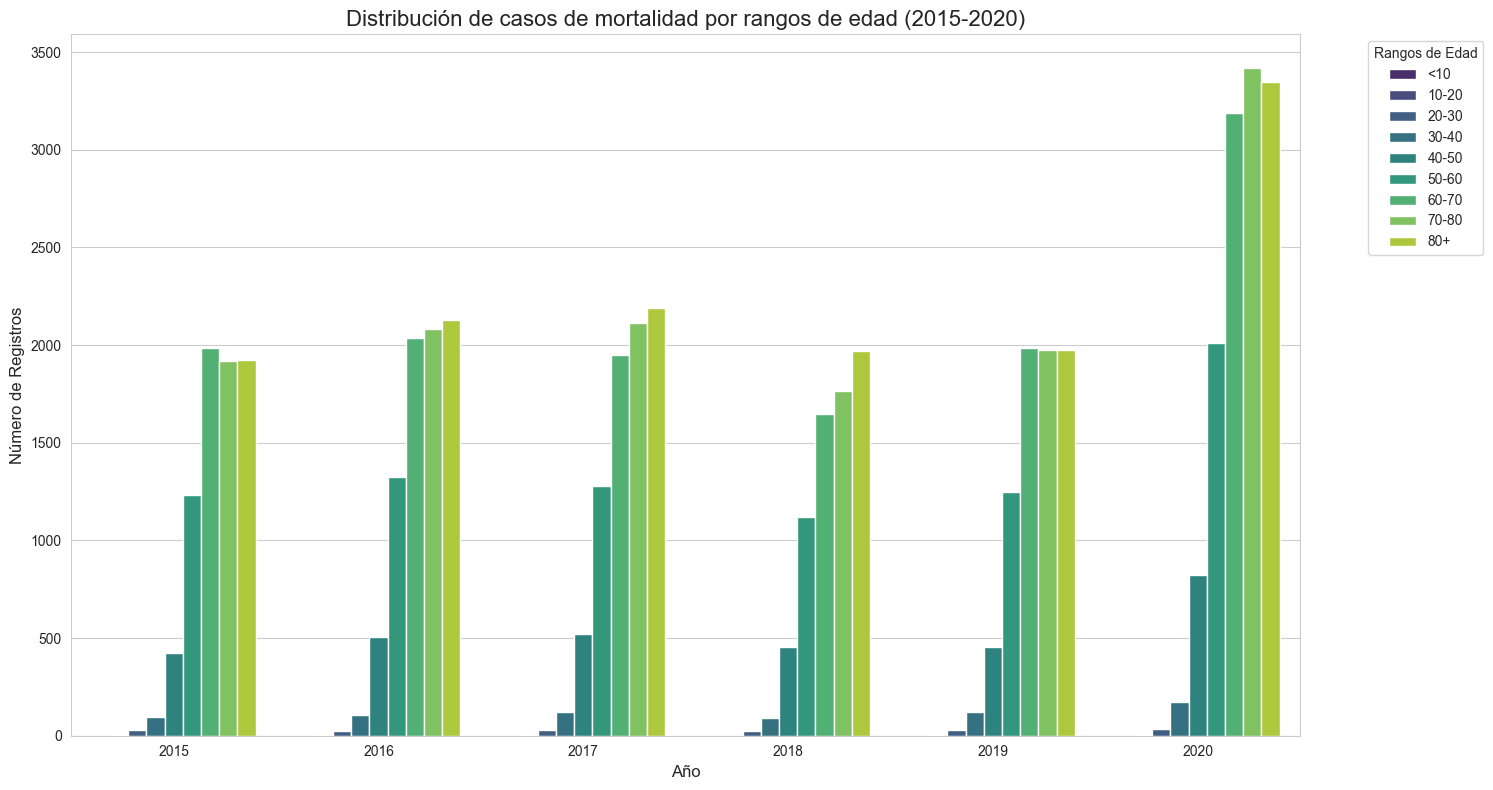

In [7]:


# 1. Definimos los cortes y las etiquetas para los rangos de edad
# Usamos 200 como límite superior para incluir "60 en adelante"
bins = [0, 10, 20, 30, 40, 50, 60,70,80, 200]
labels = ['<10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']

# 2. Creamos la nueva columna de rangos (asegúrate de que 'edad' sea numérica)
dgis['rango_edad'] = pd.cut(dgis['edad'], bins=bins, labels=labels, right=False)

# 3. Filtramos los años solicitados (2015-2020)
#df_filtrado = dgis[(dgis['año'] >= 2015) & (dgis['año'] <= 2020)].copy()

# 4. Agrupamos los datos para obtener el conteo por año y rango
df_agrupado = dgis.groupby(['año', 'rango_edad']).size().reset_index(name='conteo')

# 5. Creamos la gráfica
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

sns.barplot(data=df_agrupado, x='año', y='conteo', hue='rango_edad', palette='viridis')

# 6. Personalización
plt.title('Distribución de casos de mortalidad por rangos de edad (2015-2020)', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Registros', fontsize=12)
plt.legend(title='Rangos de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda/casosporedad.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\super\AppData\Local\Temp\ipykernel_20416\1539319593.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dgis['rango_edad_exacto'] = pd.cut(dgis['edad'], bins=bins, labels=labels, right=False)
C:\Users\super\AppData\Local\Temp\ipykernel_20416\1539319593.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_casos_edad = dgis.groupby(['año', 'rango_edad_exacto']).size().reset_index(name='conteo_casos')


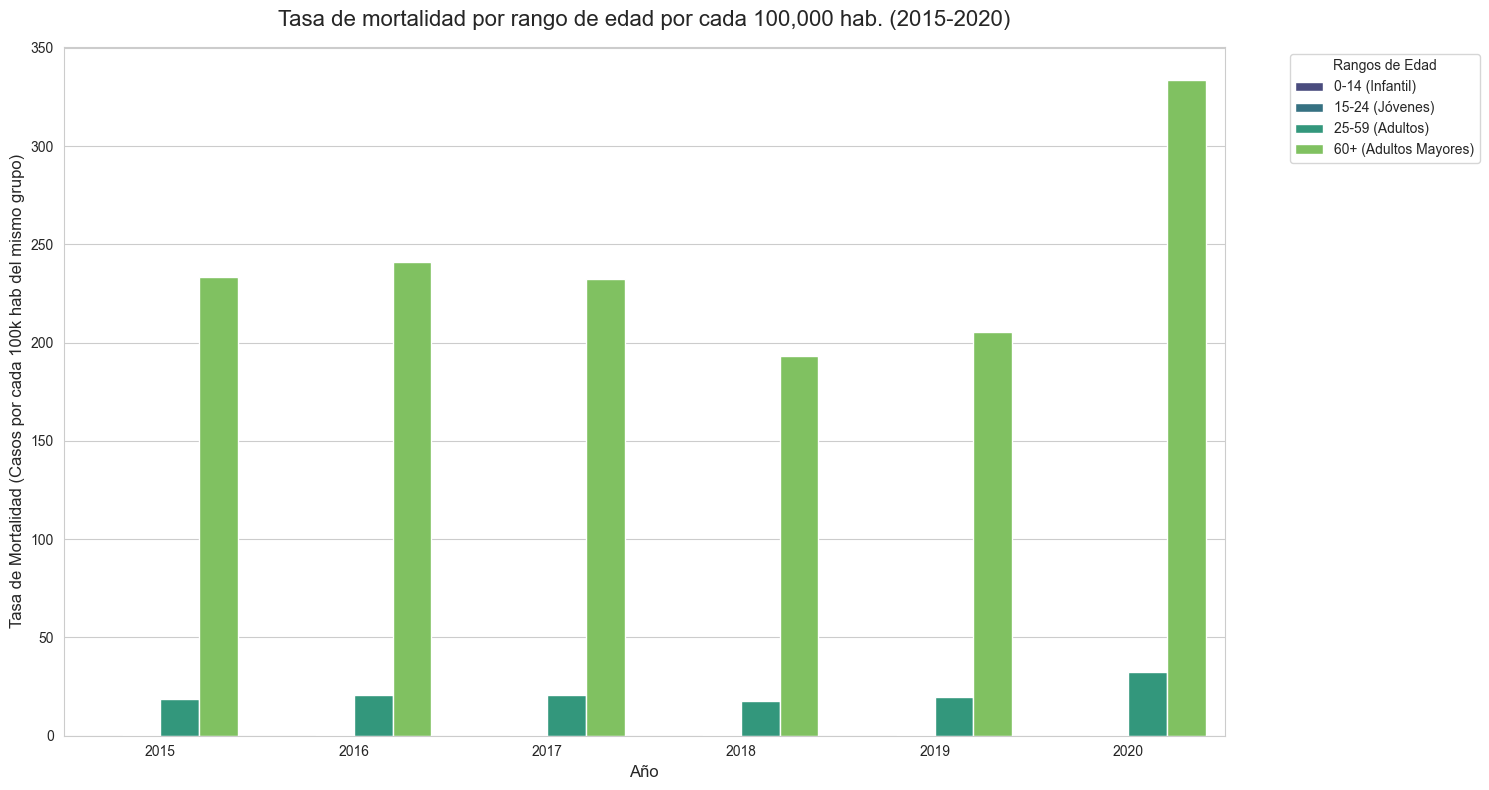

In [8]:

# 1. Definimos los cortes reales que coinciden con los grupos demográficos de tu INEGI
# Mantendremos agrupado el bloque de 60+ para que la tasa sea matemáticamente exacta con tus columnas actuales
bins = [0, 15, 25, 60, 200]
labels = ['0-14 (Infantil)', '15-24 (Jóvenes)', '25-59 (Adultos)', '60+ (Adultos Mayores)']

# 2. Creamos la columna de rangos en DGIS
dgis['rango_edad_exacto'] = pd.cut(dgis['edad'], bins=bins, labels=labels, right=False)

# 3. Agrupamos DGIS para obtener el conteo de casos por año y rango de edad a nivel CDMX
df_casos_edad = dgis.groupby(['año', 'rango_edad_exacto']).size().reset_index(name='conteo_casos')

# 4. Obtenemos la población total de la CDMX por año y grupo de edad desde el dataset INEGI
# Agrupamos por año para sumar la población de todas las alcaldías
df_pob_anio = inegi.groupby('año')[['p_0a14', 'p_15a24', 'p_25a59', 'p_60ymas']].sum().reset_index()

# 5. Reestructuramos el dataframe de población (Melt) para poder cruzarlo con los casos
df_pob_melt = df_pob_anio.melt(id_vars=['año'], 
                               value_vars=['p_0a14', 'p_15a24', 'p_25a59', 'p_60ymas'],
                               var_name='rango_edad_exacto', value_name='poblacion_grupo')

# Homologamos las etiquetas para que coincidan perfectamente al hacer el merge
mapeo_etiquetas = {
    'p_0a14': '0-14 (Infantil)',
    'p_15a24': '15-24 (Jóvenes)',
    'p_25a59': '25-59 (Adultos)',
    'p_60ymas': '60+ (Adultos Mayores)'
}
df_pob_melt['rango_edad_exacto'] = df_pob_melt['rango_edad_exacto'].replace(mapeo_etiquetas)

# 6. Cruzamos los casos con la población del grupo correspondiente
df_tasas_edad = pd.merge(df_casos_edad, df_pob_melt, on=['año', 'rango_edad_exacto'], how='inner')

# 7. Calculamos la Tasa de Mortalidad Específica por cada 100k habitantes de ese grupo
df_tasas_edad['tasa_mortalidad_100k'] = (df_tasas_edad['conteo_casos'] / df_tasas_edad['poblacion_grupo']) * 100000

# 8. Filtramos los años solicitados (2015-2020)
df_grafica = df_tasas_edad[(df_tasas_edad['año'] >= 2015) & (df_tasas_edad['año'] <= 2020)].copy()

# 9. Creamos la gráfica de barras de tasas
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# El eje Y ahora representa la Tasa de Mortalidad, reflejando el verdadero riesgo de cada grupo
sns.barplot(data=df_grafica, x='año', y='tasa_mortalidad_100k', hue='rango_edad_exacto', palette='viridis')

# 10. Personalización
plt.title('Tasa de mortalidad por rango de edad por cada 100,000 hab. (2015-2020)', fontsize=16, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (Casos por cada 100k hab del mismo grupo)', fontsize=12)
plt.legend(title='Rangos de Edad', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda/casosporedadtasa.png', dpi=300, bbox_inches='tight')
plt.show()

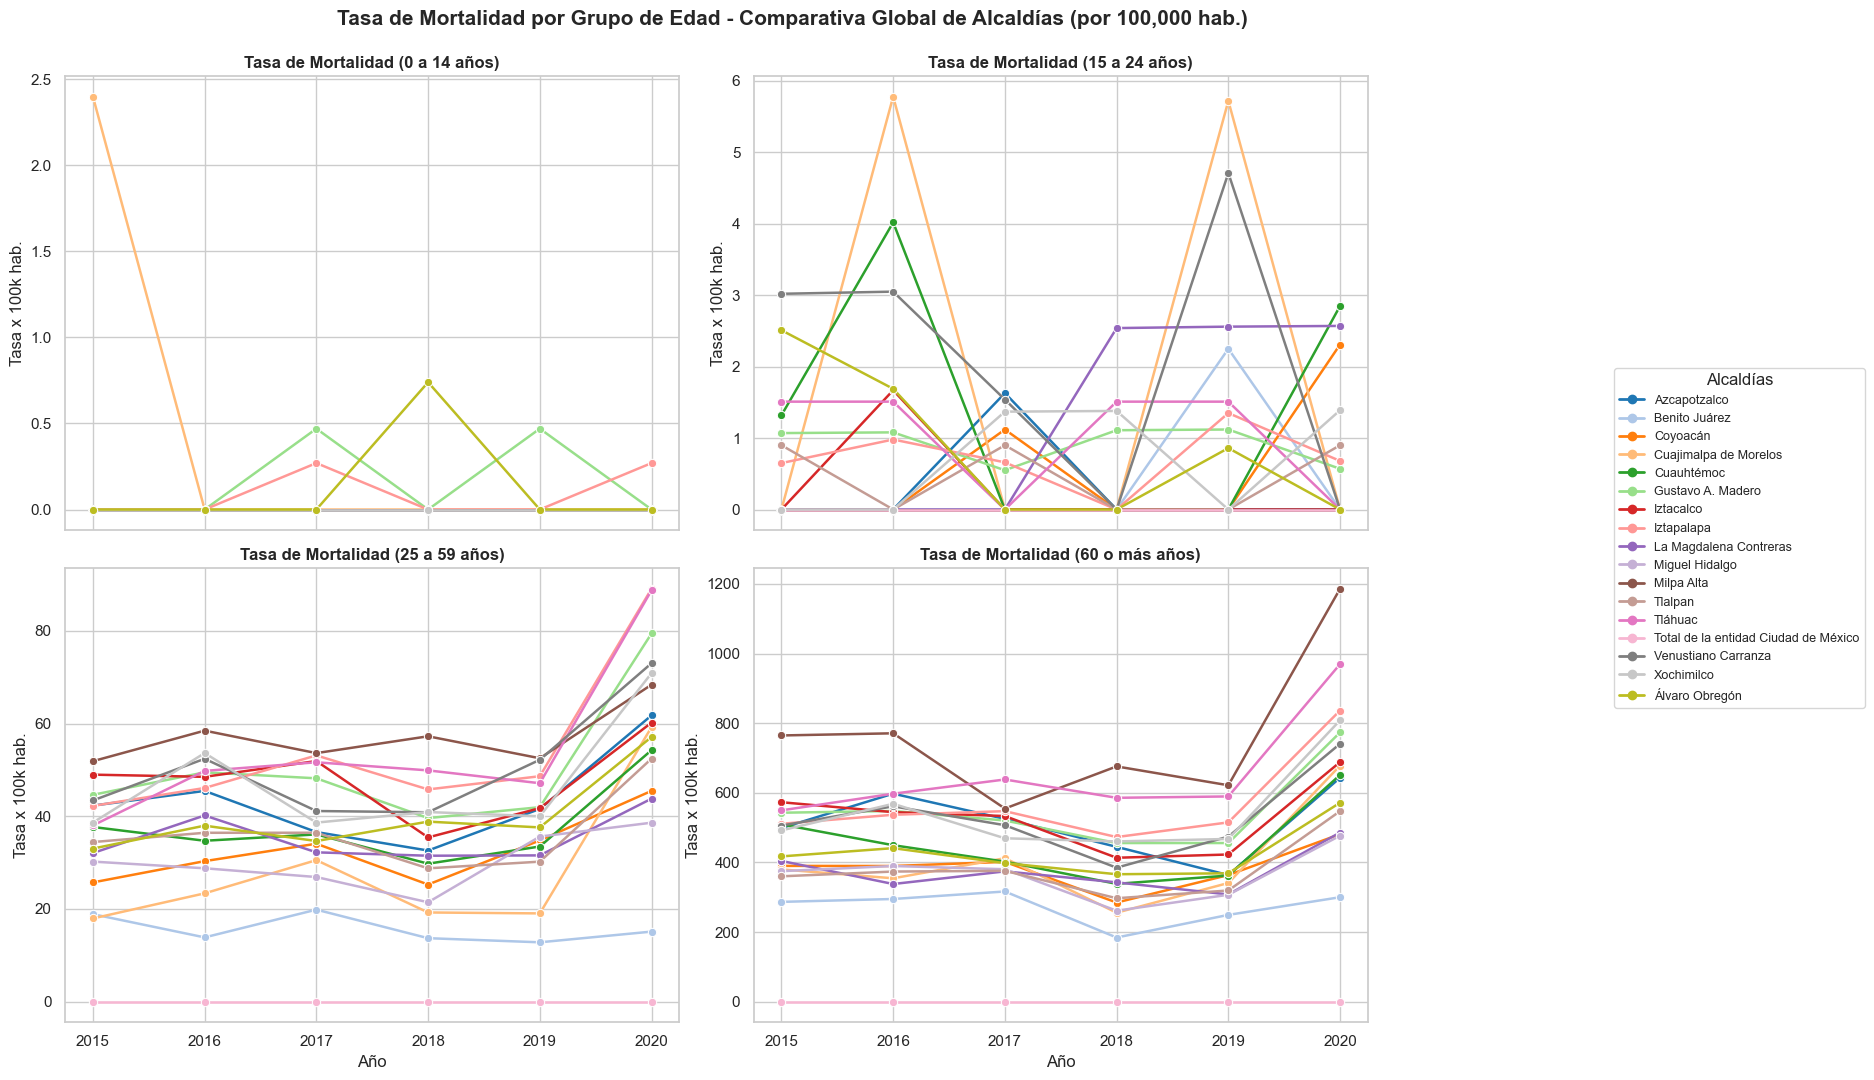

In [9]:


# ==========================================
# 1. PARÁMETROS DE FILTRADO DE TIEMPO
# ==========================================
periodo_min = 2015
periodo_max = 2020

# ==========================================
# 2. PROCESAMIENTO Y AGRUPACIÓN EN DGIS
# ==========================================
# Filtrar DGIS por rango de años
df_dgis_filt = dgis[
    (dgis['año'] >= periodo_min) & (dgis['año'] <= periodo_max)
].copy()

# Agrupar edades en los 4 rangos requeridos
condiciones = [
    (df_dgis_filt['edad'] >= 0) & (df_dgis_filt['edad'] <= 14),
    (df_dgis_filt['edad'] >= 15) & (df_dgis_filt['edad'] <= 24),
    (df_dgis_filt['edad'] >= 25) & (df_dgis_filt['edad'] <= 59),
    (df_dgis_filt['edad'] >= 60),
]
categorias = ['casos_0a14', 'casos_15a24', 'casos_25a59', 'casos_60ymas']

df_dgis_filt['rango_edad'] = np.select(
    condiciones, categorias, default='otro'
)

# Agrupar por municipio y año, contando ocurrencias por grupo de edad
dgis_agrupado = (
    df_dgis_filt[df_dgis_filt['rango_edad'] != 'otro']
    .groupby(['clave_municipio', 'año', 'rango_edad'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Asegurar que todas las columnas existan aunque no haya casos en algún rango
for col in categorias:
    if col not in dgis_agrupado.columns:
        dgis_agrupado[col] = 0

# ==========================================
# 3. UNIÓN (JOIN) CON INEGI Y CÁLCULO DE TASAS
# ==========================================
# Filtrar INEGI ÚNICAMENTE por el rango de años (tomando TODAS las alcaldías)
df_inegi_filt = inegi[
    (inegi['año'] >= periodo_min) & (inegi['año'] <= periodo_max)
].copy()

# Realizar el Merge entre DGIS (casos) e INEGI (población)
df_merged = pd.merge(
    df_inegi_filt,
    dgis_agrupado,
    left_on=['mun', 'año'],
    right_on=['clave_municipio', 'año'],
    how='left',
)

# Rellenar con 0 casos si para alguna combinación municipio/año no hubo registros en DGIS
df_merged[categorias] = df_merged[categorias].fillna(0)

# Calcular Tasas de Mortalidad / Incidencia por cada 100,000 habitantes
df_merged['tasa_0a14'] = (
    (df_merged['casos_0a14'] / df_merged['p_0a14']).replace([np.inf, -np.inf], 0).fillna(0)
    * 100000
).round(2)

df_merged['tasa_15a24'] = (
    (df_merged['casos_15a24'] / df_merged['p_15a24']).replace([np.inf, -np.inf], 0).fillna(0)
    * 100000
).round(2)

df_merged['tasa_25a59'] = (
    (df_merged['casos_25a59'] / df_merged['p_25a59']).replace([np.inf, -np.inf], 0).fillna(0)
    * 100000
).round(2)

df_merged['tasa_60ymas'] = (
    (df_merged['casos_60ymas'] / df_merged['p_60ymas']).replace([np.inf, -np.inf], 0).fillna(0)
    * 100000
).round(2)

# Ordenar los datos cronológicamente y por alcaldía
df_merged = df_merged.sort_values(by=['año', 'nom_mun'])

# ==========================================
# 4. GRAFICACIÓN CON SEABORN Y MATPLOTLIB
# ==========================================
sns.set_theme(style='whitegrid')

# Obtener número total de alcaldías para la paleta de colores dinámicas
num_alcaldias = df_merged['nom_mun'].nunique()
palette = sns.color_palette('tab20', n_colors=num_alcaldias)

# Crear figura de 2x2 para las 4 gráficas
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
fig.suptitle(
    'Tasa de Mortalidad por Grupo de Edad - Comparativa Global de Alcaldías (por 100,000 hab.)',
    fontsize=15,
    fontweight='bold',
)

grupos_config = [
    ('tasa_0a14', 'Tasa de Mortalidad (0 a 14 años)', axes[0, 0]),
    ('tasa_15a24', 'Tasa de Mortalidad (15 a 24 años)', axes[0, 1]),
    ('tasa_25a59', 'Tasa de Mortalidad (25 a 59 años)', axes[1, 0]),
    ('tasa_60ymas', 'Tasa de Mortalidad (60 o más años)', axes[1, 1]),
]

for col_tasa, titulo, ax in grupos_config:
    sns.lineplot(
        data=df_merged,
        x='año',
        y=col_tasa,
        hue='nom_mun',
        marker='o',
        linewidth=1.8,
        palette=palette,
        ax=ax,
        legend=False  # Desactivamos leyendas individuales para usar una global
    )
    ax.set_title(titulo, fontsize=12, fontweight='semibold')
    ax.set_xlabel('Año' if ax in [axes[1, 0], axes[1, 1]] else '')
    ax.set_ylabel('Tasa x 100k hab.')

# Crear una única leyenda global afuera de las gráficas a la derecha
handles, labels = axes[0, 0].get_legend_handles_labels()
if not handles:
    # Si legend=False previno la creación de handles en el Plot, extraemos las series directamente
    norm_mun_unique = df_merged['nom_mun'].unique()
    handles = [plt.Line2D([0], [0], color=palette[i], lw=2, marker='o') for i in range(len(norm_mun_unique))]
    labels = list(norm_mun_unique)

fig.legend(
    handles=handles,
    labels=labels,
    title='Alcaldías',
    bbox_to_anchor=(1.01, 0.5),
    loc='center left',
    frameon=True,
    fontsize=9
)

# Ajustar márgenes para que la leyenda externa encaje perfectamente
plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.86)
plt.savefig('eda/casosporedadtasaalcaldias.png', dpi=300, bbox_inches='tight')

plt.show()

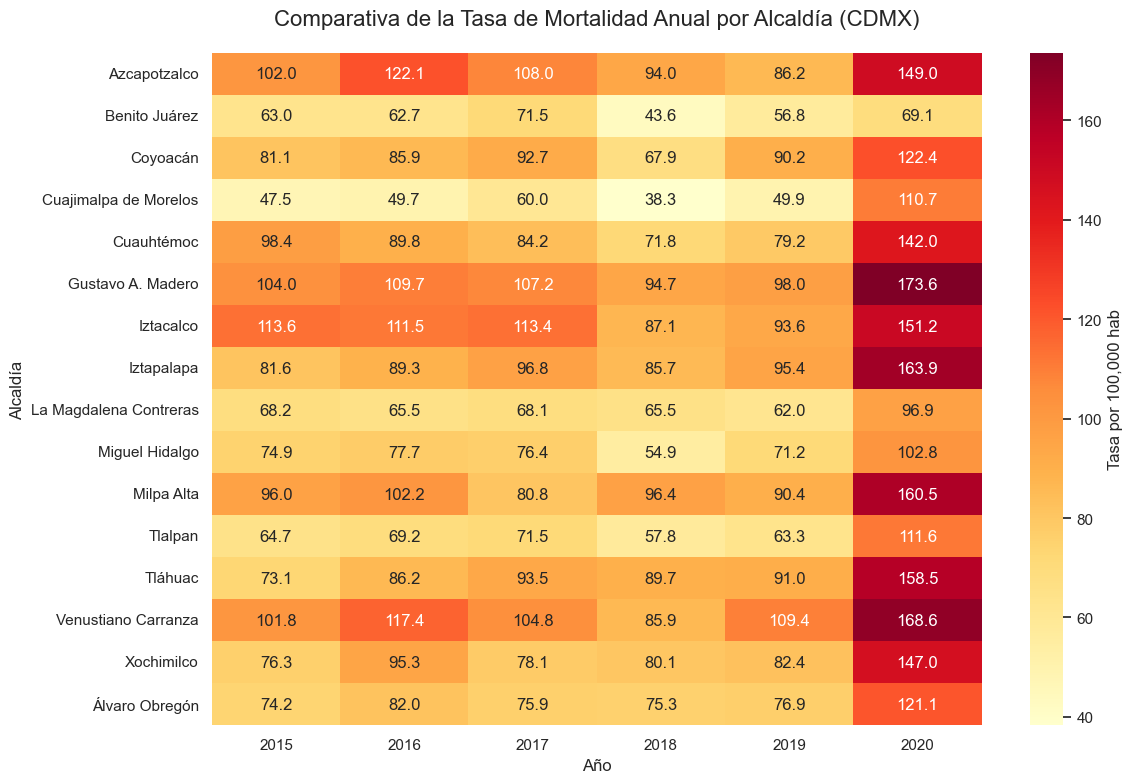

In [10]:


# 1. Contar defunciones por año y municipio en DGIS
# Agrupamos para obtener el número bruto de casos por alcaldía y año
df_casos_año = dgis.groupby(['año', 'clave_municipio']).size().reset_index(name='total_casos')

# 2. Homologar columnas clave en INEGI para poder hacer el Merge
# Tu dataset de INEGI tiene 'mun' y 'año'. Asegúrate de que coincidan los tipos de datos (int).
inegi_subset = inegi[['año', 'mun', 'nom_mun', 'pobtot']].copy()
inegi_subset = inegi_subset.rename(columns={'mun': 'clave_municipio'})

# 3. Cruzar los datasets (Merge)
df_tasas = pd.merge(df_casos_año, inegi_subset, on=['año', 'clave_municipio'], how='inner')

# 4. Calcular la Tasa de Mortalidad por cada 100k habitantes
df_tasas['tasa_mortalidad_100k'] = (df_tasas['total_casos'] / df_tasas['pobtot']) * 100000

# Quitamos registros que representen el total de la entidad si es que existen (ej. clave 0)
df_tasas = df_tasas[df_tasas['clave_municipio'] != 0]
df_tasasMortalidad = df_tasas
# Pivotamos los datos para tener los años en las columnas y las alcaldías en las filas
df_pivot = df_tasas.pivot(index='nom_mun', columns='año', values='tasa_mortalidad_100k')

plt.figure(figsize=(12, 8))
sns.set_style("white")

# Creamos el mapa de calor
sns.heatmap(df_pivot, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Tasa por 100,000 hab'})

plt.title('Comparativa de la Tasa de Mortalidad Anual por Alcaldía (CDMX)', fontsize=16, pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Alcaldía', fontsize=12)

plt.tight_layout()
plt.savefig('eda/TasaMortalidad.png', dpi=300, bbox_inches='tight')

plt.show()

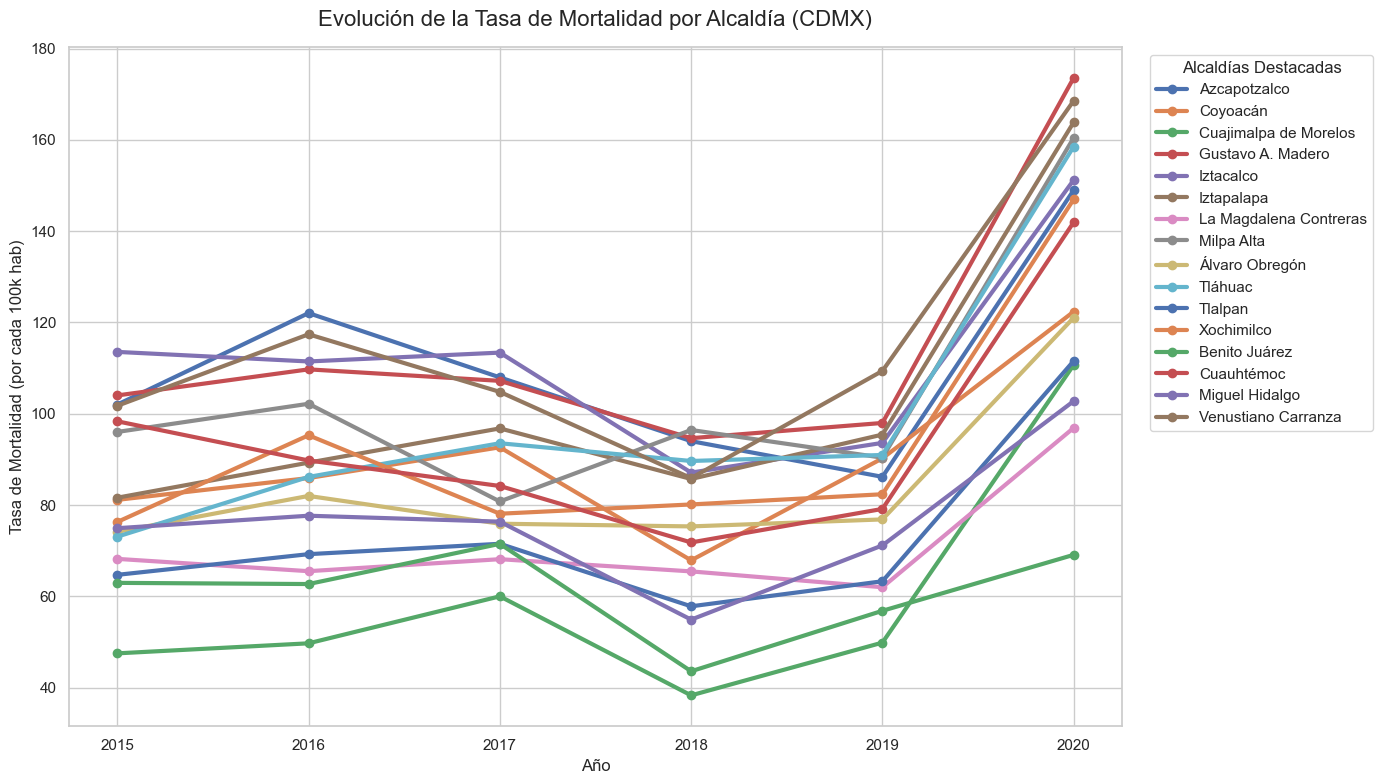

In [11]:


plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 1. Identificar las 3 alcaldías con mayor tasa en el último año para destacarlas
ultimo_anio = df_tasas['año'].max()
#top_alcaldias = (df_tasas[df_tasas['año'] == ultimo_anio]
#                 .sort_values(by='tasa_mortalidad_100k', ascending=False)
#                 .head(5)['nom_mun'].tolist())

# 2. Graficar cada alcaldía
for alcaldia in df_tasas['nom_mun'].unique():
    df_alca = df_tasas[df_tasas['nom_mun'] == alcaldia].sort_values(by='año')
    
    # Si es una de las alcaldías top, la pintamos con color fuerte y más gruesa
 #   if alcaldia in top_alcaldias:
    plt.plot(df_alca['año'], df_alca['tasa_mortalidad_100k'], 
            marker='o', linewidth=3, label=f'{alcaldia}', zorder=5)
  #  else:
        # Si no, la pintamos gris y más delgada para evitar el "efecto espagueti"
   #     plt.plot(df_alca['año'], df_alca['tasa_mortalidad_100k'], 
    #             color='lightgray', alpha=0.7, linewidth=1.5, zorder=2)

# 3. Personalización de la gráfica
plt.title('Evolución de la Tasa de Mortalidad por Alcaldía (CDMX)', fontsize=16, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (por cada 100k hab)', fontsize=12)

# Asegurar que los años se muestren como enteros en el eje X
plt.xticks(sorted(df_tasas['año'].unique()))

# Colocar la leyenda fuera de la gráfica para que no estorbe
plt.legend(title='Alcaldías Destacadas', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda/TasaMortalidadevolucion.png', dpi=300, bbox_inches='tight')

plt.show()

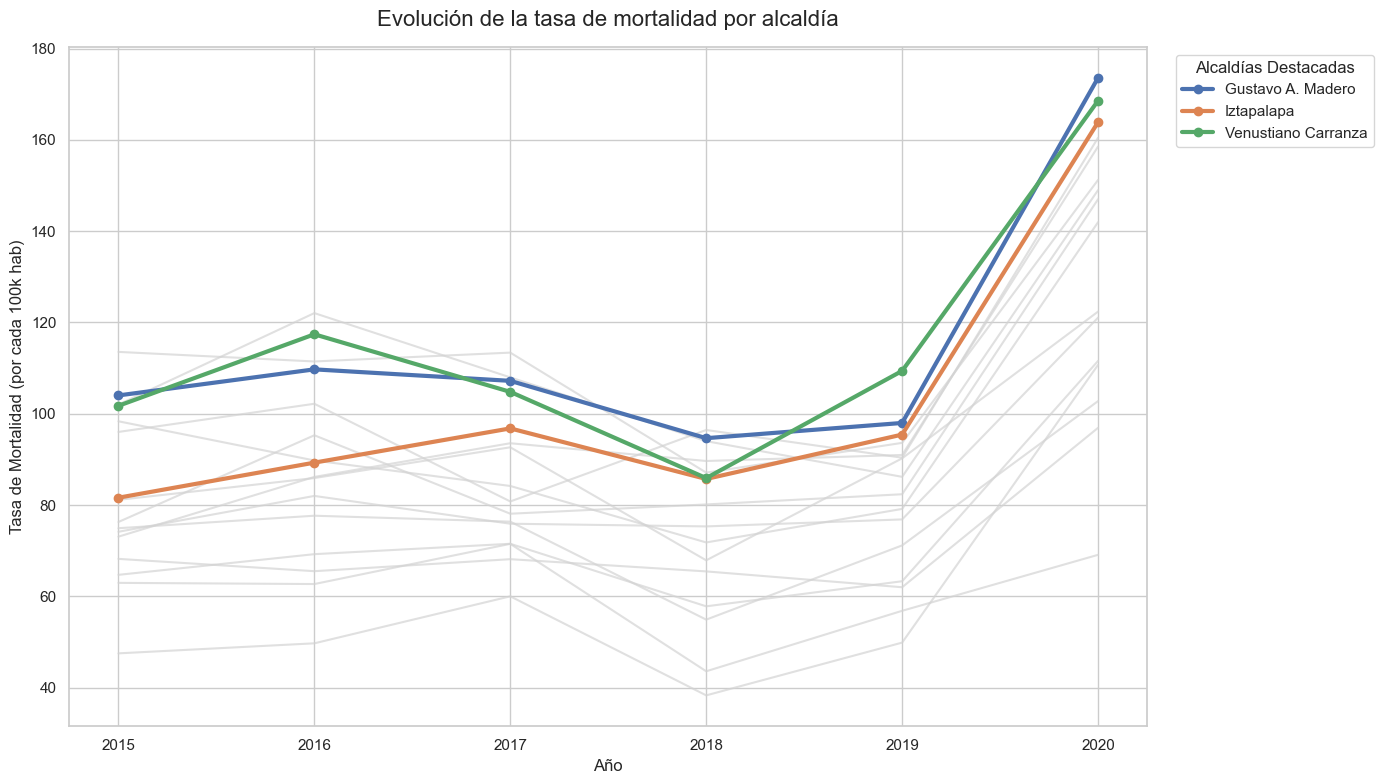

In [12]:


plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 1. Identificar las 3 alcaldías con mayor tasa en el último año para destacarlas
ultimo_anio = df_tasas['año'].max()
top_alcaldias = (df_tasas[df_tasas['año'] == ultimo_anio]
                 .sort_values(by='tasa_mortalidad_100k', ascending=False)
                 .head(3)['nom_mun'].tolist())

# 2. Graficar cada alcaldía
for alcaldia in df_tasas['nom_mun'].unique():
    df_alca = df_tasas[df_tasas['nom_mun'] == alcaldia].sort_values(by='año')
    
    # Si es una de las alcaldías top, la pintamos con color fuerte y más gruesa
    if alcaldia in top_alcaldias:
        plt.plot(df_alca['año'], df_alca['tasa_mortalidad_100k'], 
                 marker='o', linewidth=3, label=f'{alcaldia}', zorder=5)
    else:
        # Si no, la pintamos gris y más delgada para evitar el "efecto espagueti"
        plt.plot(df_alca['año'], df_alca['tasa_mortalidad_100k'], 
                 color='lightgray', alpha=0.7, linewidth=1.5, zorder=2)

# 3. Personalización de la gráfica
plt.title('Evolución de la tasa de mortalidad por alcaldía', fontsize=16, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (por cada 100k hab)', fontsize=12)

# Asegurar que los años se muestren como enteros en el eje X
plt.xticks(sorted(df_tasas['año'].unique()))

# Colocar la leyenda fuera de la gráfica para que no estorbe
plt.legend(title='Alcaldías Destacadas', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda/TasaMortalidadtop.png', dpi=300, bbox_inches='tight')

plt.show()

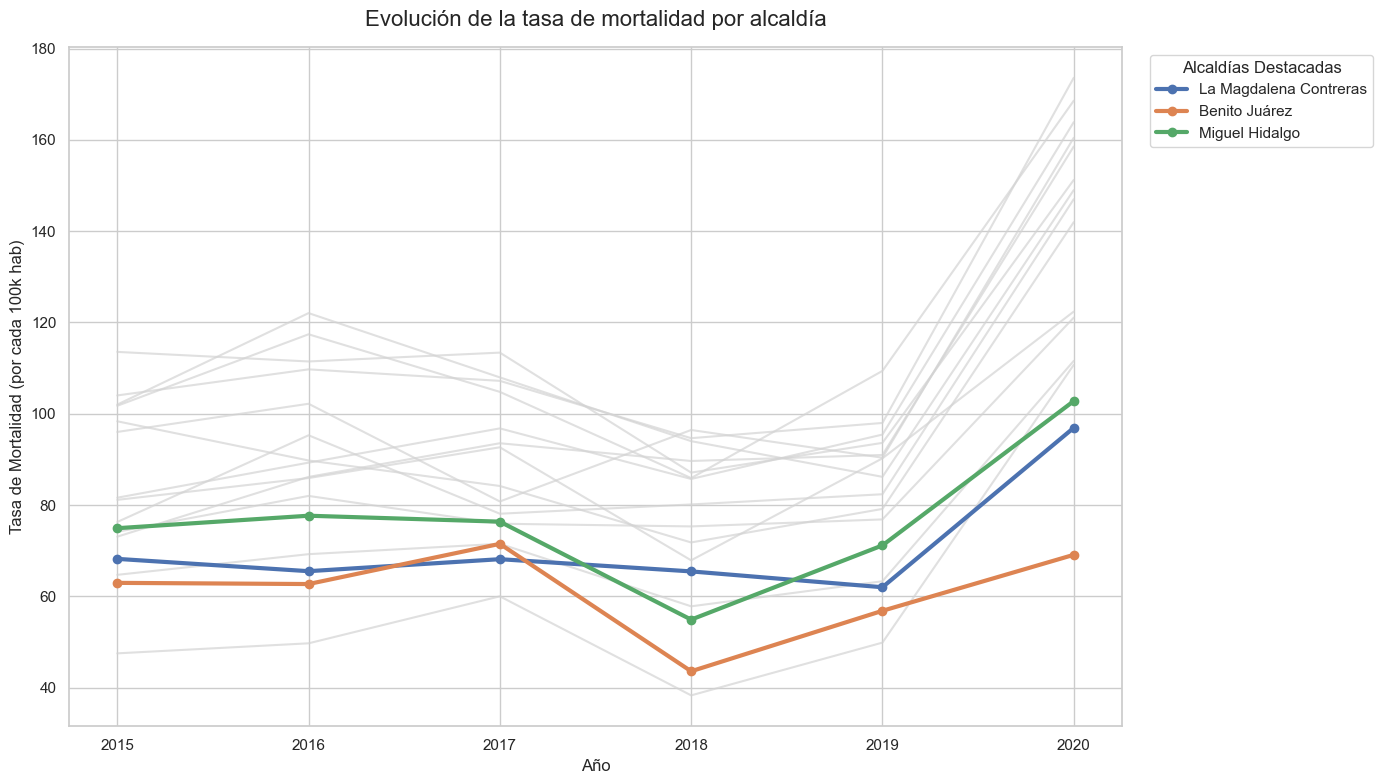

In [13]:


plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# 1. Identificar las 3 alcaldías con mayor tasa en el último año para destacarlas
ultimo_anio = df_tasas['año'].max()
top_alcaldias = (df_tasas[df_tasas['año'] == ultimo_anio]
                 .sort_values(by='tasa_mortalidad_100k', ascending=False)
                 .tail(3)['nom_mun'].tolist())

# 2. Graficar cada alcaldía
for alcaldia in df_tasas['nom_mun'].unique():
    df_alca = df_tasas[df_tasas['nom_mun'] == alcaldia].sort_values(by='año')
    
    # Si es una de las alcaldías top, la pintamos con color fuerte y más gruesa
    if alcaldia in top_alcaldias:
        plt.plot(df_alca['año'], df_alca['tasa_mortalidad_100k'], 
                 marker='o', linewidth=3, label=f'{alcaldia}', zorder=5)
    else:
        # Si no, la pintamos gris y más delgada para evitar el "efecto espagueti"
        plt.plot(df_alca['año'], df_alca['tasa_mortalidad_100k'], 
                 color='lightgray', alpha=0.7, linewidth=1.5, zorder=2)

# 3. Personalización de la gráfica
plt.title('Evolución de la tasa de mortalidad por alcaldía', fontsize=16, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (por cada 100k hab)', fontsize=12)

# Asegurar que los años se muestren como enteros en el eje X
plt.xticks(sorted(df_tasas['año'].unique()))

# Colocar la leyenda fuera de la gráfica para que no estorbe
plt.legend(title='Alcaldías Destacadas', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('eda/TasaMortalidadtail.png', dpi=300, bbox_inches='tight')

plt.show()

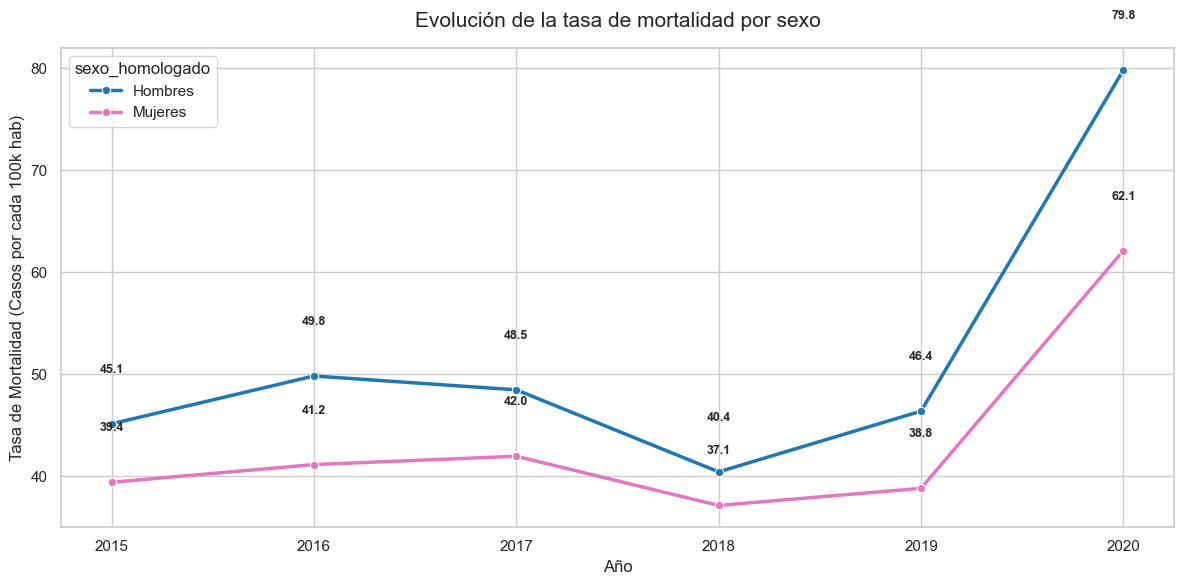

In [14]:


# 1. Contar los casos por año y sexo en DGIS
# Nota: Verifica si en tu columna 'sexo' los valores vienen como 1 y 2, o como texto ('Hombres'/'Mujeres')
df_casos_sexo = dgis.groupby(['año', 'sexo']).size().reset_index(name='conteo_casos')

# 2. Obtener la población total de hombres y mujeres de la CDMX por año desde INEGI
df_pob_sexo = inegi.groupby('año')[['pobmas', 'pobfem']].sum().reset_index()

# 3. Reestructurar el dataset de población (Melt) para poder unirlo
df_pob_sexo_melt = df_pob_sexo.melt(id_vars=['año'], 
                                     value_vars=['pobmas', 'pobfem'],
                                     var_name='sexo_inegi', value_name='poblacion_total')

# 4. Homologar las claves de la columna 'sexo' para que coincidan en el Merge
# Si tu DGIS usa 1 para Hombres y 2 para Mujeres, el mapeo se hace así:
mapeo_sexo = {
    1: 'Hombres',
    2: 'Mujeres',
    '1': 'Hombres', # Por si acaso vienen como string
    '2': 'Mujeres',
    'M': 'Hombres', # Ajusta este mapeo según los valores reales de tu columna df['sexo'].unique()
    'F': 'Mujeres'
}
df_casos_sexo['sexo_homologado'] = df_casos_sexo['sexo'].replace(mapeo_sexo)

mapeo_inegi = {
    'pobmas': 'Hombres',
    'pobfem': 'Mujeres'
}
df_pob_sexo_melt['sexo_homologado'] = df_pob_sexo_melt['sexo_inegi'].replace(mapeo_inegi)

# 5. Combinar los datasets
df_tasas_sexo = pd.merge(df_casos_sexo, df_pob_sexo_melt, on=['año', 'sexo_homologado'], how='inner')

# 6. Calcular la Tasa de Mortalidad por cada 100k habitantes de ese mismo sexo
df_tasas_sexo['tasa_100k'] = (df_tasas_sexo['conteo_casos'] / df_tasas_sexo['poblacion_total']) * 100000

# Filtramos para el periodo de tu análisis (2015-2020)
df_tasas_sexo = df_tasas_sexo[(df_tasas_sexo['año'] >= 2015) & (df_tasas_sexo['año'] <= 2020)].sort_values('año')

# 7. Graficar
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Dibujamos las líneas para Hombres y Mujeres con una paleta contrastante
sns.lineplot(data=df_tasas_sexo, x='año', y='tasa_100k', hue='sexo_homologado', 
             marker='o', linewidth=2.5, palette={'Hombres': '#1f77b4', 'Mujeres': '#e377c2'})

# Personalización
plt.title('Evolución de la tasa de mortalidad por sexo', fontsize=15, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (Casos por cada 100k hab)', fontsize=12)
plt.xticks(sorted(df_tasas_sexo['año'].unique()))

# Añadir los valores numéricos sobre los puntos para facilitar la lectura en tu reporte
for entre, fila in df_tasas_sexo.iterrows():
    plt.text(fila['año'], fila['tasa_100k'] + 5, f"{fila['tasa_100k']:.1f}", 
             ha='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.savefig('eda/TasaMortalidadsexo.png', dpi=300, bbox_inches='tight')
plt.show()

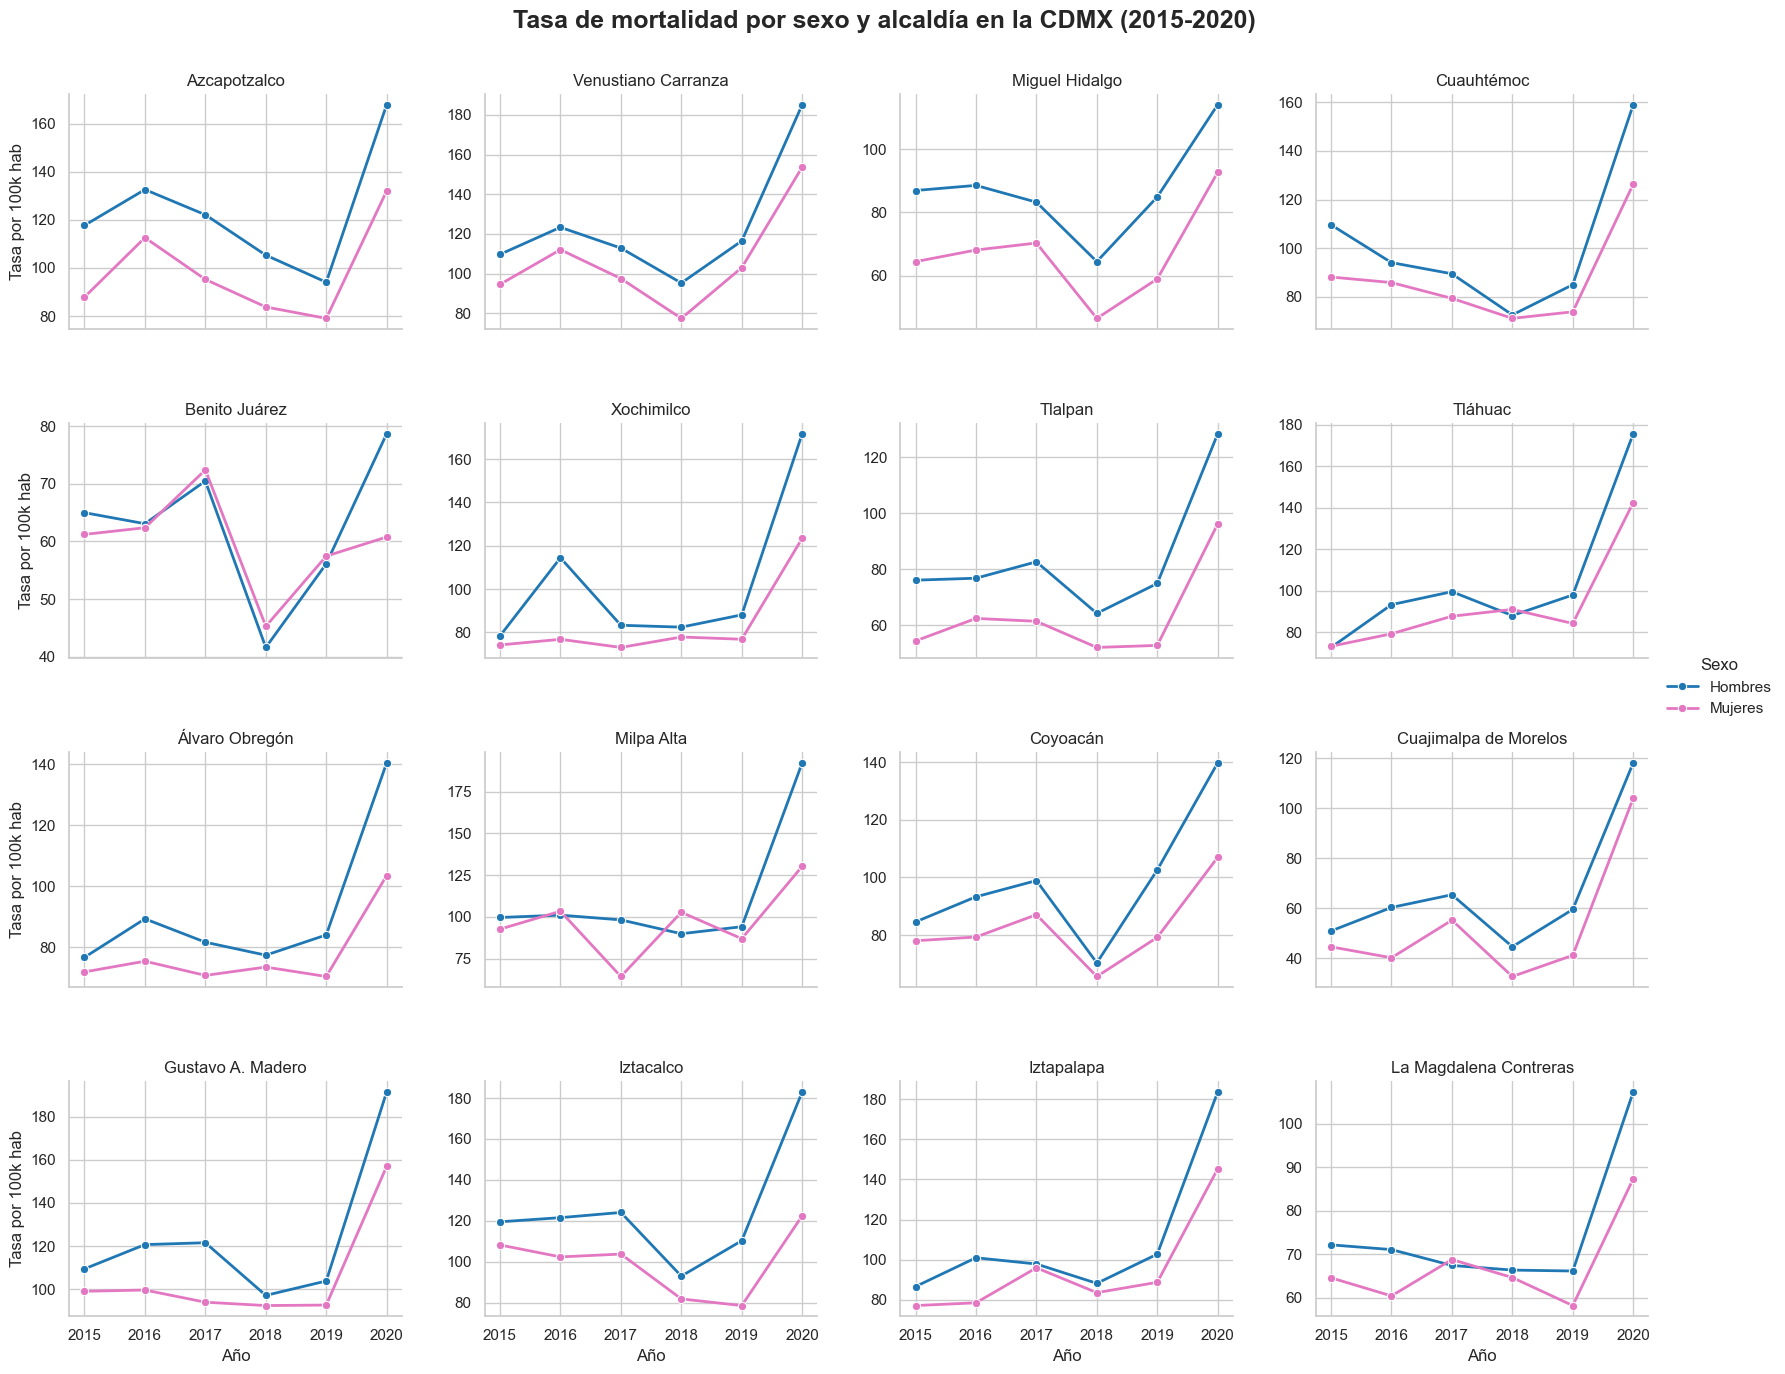

In [15]:


# 1. Contar los casos por año, municipio y sexo en DGIS
df_casos_mun_sexo = dgis.groupby(['año', 'clave_municipio', 'sexo']).size().reset_index(name='conteo_casos')

# 2. Seleccionar las poblaciones por municipio y año de INEGI
# Renombramos 'mun' a 'clave_municipio' para el cruce
inegi_mun_sexo = inegi[['año', 'mun', 'nom_mun', 'pobmas', 'pobfem']].copy()
inegi_mun_sexo = inegi_mun_sexo.rename(columns={'mun': 'clave_municipio'})

# 3. Reestructurar el dataset demográfico (Melt) para tener el sexo en las filas
df_pob_melt = inegi_mun_sexo.melt(
    id_vars=['año', 'clave_municipio', 'nom_mun'], 
    value_vars=['pobmas', 'pobfem'],
    var_name='sexo_inegi', 
    value_name='poblacion_total'
)

# 4. Homologar las etiquetas de sexo
mapeo_sexo = {
    1: 'Hombres', 2: 'Mujeres',
    '1': 'Hombres', '2': 'Mujeres',
    'M': 'Hombres', 'F': 'Mujeres'
}
df_casos_mun_sexo['sexo_homologado'] = df_casos_mun_sexo['sexo'].replace(mapeo_sexo)

mapeo_inegi = {'pobmas': 'Hombres', 'pobfem': 'Mujeres'}
df_pob_melt['sexo_homologado'] = df_pob_melt['sexo_inegi'].replace(mapeo_inegi)

# 5. Combinar datasets por año, municipio y sexo
df_tasas_mun_sexo = pd.merge(
    df_casos_mun_sexo, 
    df_pob_melt, 
    on=['año', 'clave_municipio', 'sexo_homologado'], 
    how='inner'
)

# Quitar la clave 0 (si representa el total estatal) para dejar solo las alcaldías
df_tasas_mun_sexo = df_tasas_mun_sexo[df_tasas_mun_sexo['clave_municipio'] != 0]

# 6. Calcular la Tasa de Mortalidad por cada 100k habitantes de ese sexo y alcaldía
df_tasas_mun_sexo['tasa_100k'] = (df_tasas_mun_sexo['conteo_casos'] / df_tasas_mun_sexo['poblacion_total']) * 100000

# Filtrar los años de tu análisis (2015-2020)
df_final = df_tasas_mun_sexo[(df_tasas_mun_sexo['año'] >= 2015) & (df_tasas_mun_sexo['año'] <= 2020)].copy()
df_final = df_final.sort_values(by='año')
df_tasasSexo=df_final

# 7. Crear la cuadrícula de gráficas (FacetGrid)
# Organizado en 4 columnas para que queden distribuidas las 16 alcaldías de forma simétrica
g = sns.FacetGrid(
    df_final, 
    col="nom_mun", 
    hue="sexo_homologado", 
    col_wrap=4, 
    height=3.5, 
    aspect=1.2,
    palette={'Hombres': '#1f77b4', 'Mujeres': '#e377c2'},
    sharey=False # Permite que cada alcaldía tenga su propia escala si sus poblaciones son muy distintas
)

# Mapear la gráfica de líneas a la cuadrícula
g.map(sns.lineplot, "año", "tasa_100k", marker="o", linewidth=2)

# Personalización y formato de ejes
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Año", "Tasa por 100k hab")
g.add_legend(title="Sexo")

# Ajustes de espaciado del título general
g.fig.subplots_adjust(top=0.92, hspace=0.4, wspace=0.25)
g.fig.suptitle('Tasa de mortalidad por sexo y alcaldía en la CDMX (2015-2020)', fontsize=18, fontweight='bold')
plt.savefig('eda/TasaMortalidadsexoAlcaldia.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
df_tasas_mun_sexo

,año,clave_municipio,sexo,conteo_casos,sexo_homologado,nom_mun,sexo_inegi,poblacion_total,tasa_100k
0,2015,2,1,236,Hombres,Azcapotzalco,pobmas,200502.0,117.704562
1,2015,2,2,196,Mujeres,Azcapotzalco,pobfem,222956.0,87.909722
2,2015,3,1,246,Hombres,Coyoacán,pobmas,290800.0,84.594223
3,2015,3,2,255,Mujeres,Coyoacán,pobfem,326631.0,78.069748
4,2015,4,1,49,Hombres,Cuajimalpa de Morelos,pobmas,96396.0,50.831985
...,...,...,...,...,...,...,...,...,...
187,2020,15,2,360,Mujeres,Cuauhtémoc,pobfem,284933.0,126.345492
188,2020,16,1,223,Hombres,Miguel Hidalgo,pobmas,195467.0,114.085754
189,2020,16,2,203,Mujeres,Miguel Hidalgo,pobfem,219003.0,92.692794
190,2020,17,1,389,Hombres,Venustiano Carranza,pobmas,210118.0,185.134068


C:\Users\super\AppData\Local\Temp\ipykernel_20416\1698192668.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dgis['escolaridad_limpia'] = dgis['escolarida'].map(mapeo_escolaridad).fillna('No Especificado')


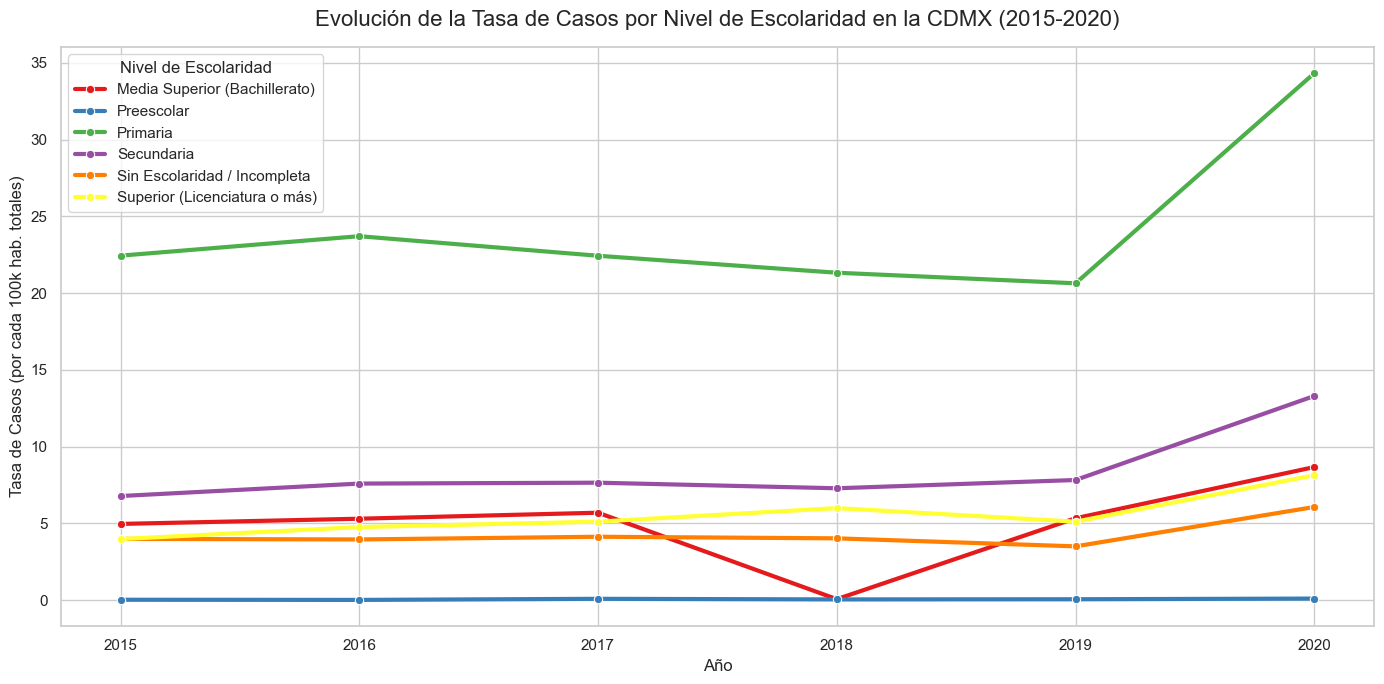

In [17]:

# 1. Conocer los valores actuales de tu columna para el mapeo
# (Ajusta los textos del diccionario de abajo según lo que devuelva este print si es necesario)
# print(dgis['escolarida'].unique())

# 2. Creamos un diccionario para estandarizar las categorías de escolaridad
# Este mapeo agrupa la diversidad de capturas en bloques epidemiológicos limpios
mapeo_escolaridad = {
    1: 'Sin Escolaridad / Incompleta',
    2: 'Preescolar',
    3: 'Primaria',
    4: 'Primaria',
    5: 'Secundaria',
    6: 'Secundaria',
    7: 'Media Superior (Bachillerato)',
    8: 'Media Superior (Bachillerato)',
    9: 'Superior (Licenciatura o más)',
    10: 'Superior (Licenciatura o más)',
    # Si tus datos vienen codificados como números (ej. 1, 2, 3), mapea los números aquí:
    # 1: 'Sin Escolaridad / Incompleta', 2: 'Básica (Primaria/Secundaria)', etc.
}

# Aplicamos el mapeo creando una columna limpia
dgis['escolaridad_limpia'] = dgis['escolarida'].map(mapeo_escolaridad).fillna('No Especificado')

# 3. Contamos los casos por año y el nuevo bloque de escolaridad
df_casos_esc = dgis.groupby(['año', 'escolaridad_limpia']).size().reset_index(name='conteo_casos')

# Quitar las filas donde no se especificó la escolaridad para no sesgar el análisis visual
df_casos_esc = df_casos_esc[df_casos_esc['escolaridad_limpia'] != 'No Especificado']

# 4. Traer la población total de la CDMX por año desde el dataset INEGI
df_pob_total = inegi.groupby('año')['pobtot'].sum().reset_index()

# 5. Combinar los datasets para obtener la tasa estandarizada
df_tasas_esc = pd.merge(df_casos_esc, df_pob_total, on='año', how='inner')

# 6. Calcular la tasa por cada 100k habitantes de la CDMX
df_tasas_esc['tasa_100k'] = (df_tasas_esc['conteo_casos'] / df_tasas_esc['pobtot']) * 100000

# Filtrar para el periodo del estudio (2015-2020)
df_tasas_esc = df_tasas_esc[(df_tasas_esc['año'] >= 2015) & (df_tasas_esc['año'] <= 2020)].sort_values('año')

# 7. Graficar la evolución temporal por nivel educativo
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Usamos una gráfica de líneas para observar trayectorias y cruces a lo largo del tiempo
sns.lineplot(
    data=df_tasas_esc, 
    x='año', 
    y='tasa_100k', 
    hue='escolaridad_limpia', 
    marker='o', 
    linewidth=3,
    palette='Set1'
)

# Personalización estétitca
plt.title('Evolución de la Tasa de Casos por Nivel de Escolaridad en la CDMX (2015-2020)', fontsize=16, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Casos (por cada 100k hab. totales)', fontsize=12)
plt.xticks(sorted(df_tasas_esc['año'].unique()))
plt.legend(title='Nivel de Escolaridad', loc='upper left')

plt.tight_layout()
plt.savefig('eda/TasaMortalidadEscolaridad.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\super\AppData\Local\Temp\ipykernel_20416\920024075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dgis['escolaridad_limpia'] = dgis['escolarida'].map(mapeo_escolaridad).fillna('No Especificado')


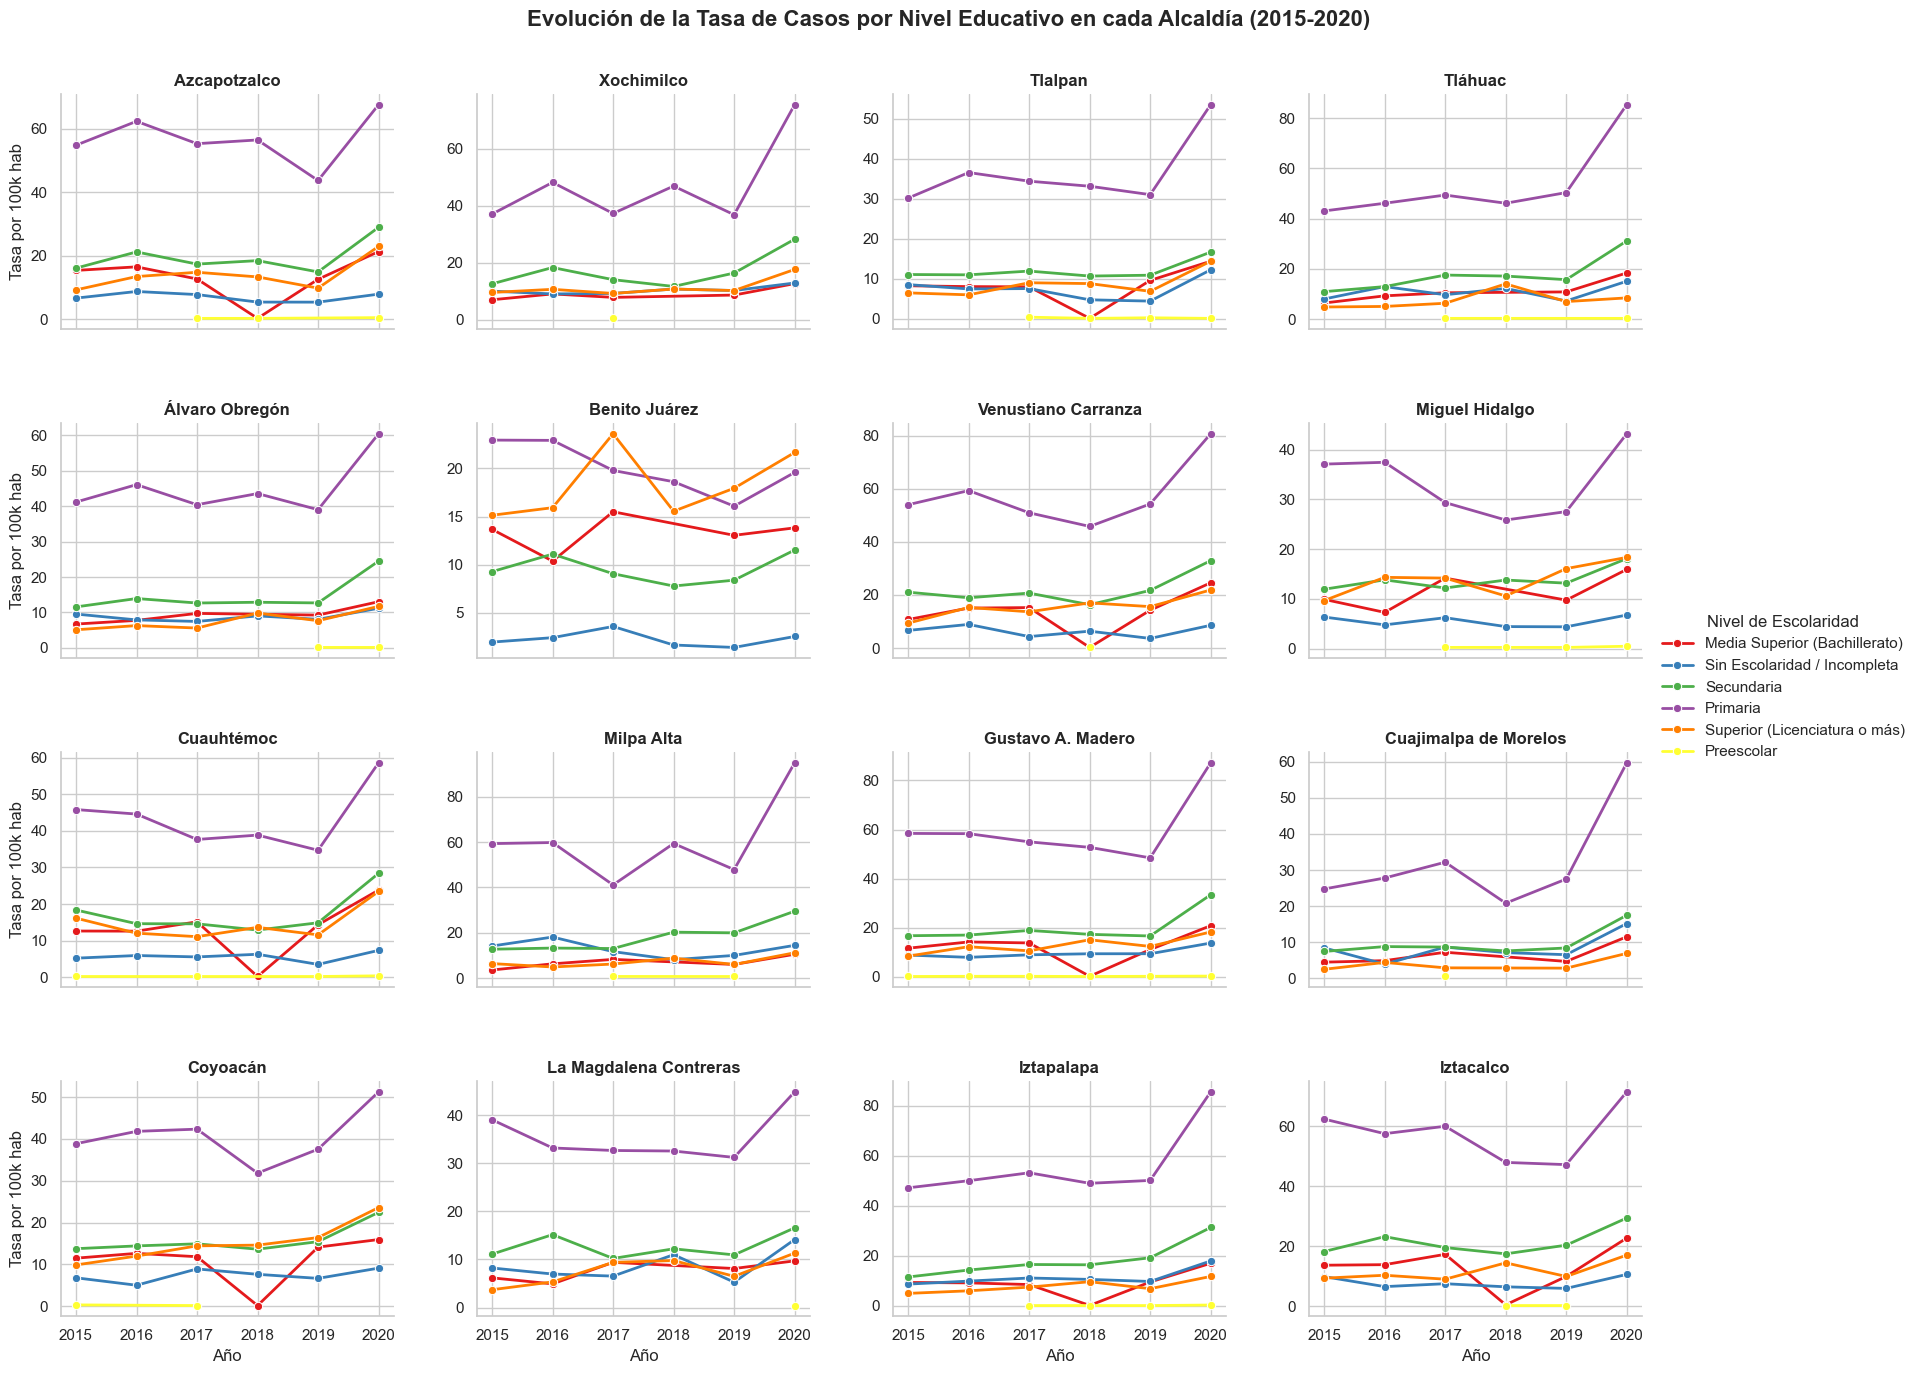

In [18]:


dgis['escolaridad_limpia'] = dgis['escolarida'].map(mapeo_escolaridad).fillna('No Especificado')

# 2. Contar casos por Año, Alcaldía y Escolaridad en DGIS
df_casos_mun_esc = dgis.groupby(['año', 'clave_municipio', 'escolaridad_limpia']).size().reset_index(name='conteo_casos')
df_casos_mun_esc = df_casos_mun_esc[df_casos_mun_esc['escolaridad_limpia'] != 'No Especificado']

# 3. Traer la población total por municipio y año desde INEGI
inegi_subset = inegi[['año', 'mun', 'nom_mun', 'pobtot']].copy()
inegi_subset = inegi_subset.rename(columns={'mun': 'clave_municipio'})

# 4. Combinar datasets
df_tasas_mun_esc = pd.merge(df_casos_mun_esc, inegi_subset, on=['año', 'clave_municipio'], how='inner')

# Filtrar para quitar la clave 0 (totales) y quedarnos solo con el periodo 2015-2020
df_tasas_mun_esc = df_tasas_mun_esc[df_tasas_mun_esc['clave_municipio'] != 0]
df_final = df_tasas_mun_esc[(df_tasas_mun_esc['año'] >= 2015) & (df_tasas_mun_esc['año'] <= 2020)].copy()

# 5. Calcular la Tasa por cada 100k habitantes de la alcaldía
df_final['tasa_100k'] = (df_final['conteo_casos'] / df_final['pobtot']) * 100000
df_final = df_final.sort_values(by='año')
df_tasaEscolaridad = df_final

# 6. Crear el FacetGrid: Una celda por cada Alcaldía
# Organizamos en 4 columnas para tener una cuadrícula perfecta de 4x4 (16 alcaldías)
g = sns.FacetGrid(
    df_final, 
    col="nom_mun", 
    hue="escolaridad_limpia", 
    col_wrap=4, 
    height=3.5, 
    aspect=1.2,
    palette='Set1',
    sharey=False # Falso para que las alcaldías con menos población no se vean "aplastadas"
)

# Mapeamos la gráfica de líneas a cada celda
g.map(sns.lineplot, "año", "tasa_100k", marker="o", linewidth=2)

# 7. Personalización de la cuadrícula
g.set_titles(col_template="{col_name}", size=12, weight='bold')
g.set_axis_labels("Año", "Tasa por 100k hab")
g.set(xticks=sorted(df_final['año'].unique()))

# Añadir la leyenda de los niveles de escolaridad
g.add_legend(title="Nivel de Escolaridad")

# Ajustes de espaciado para el título principal
g.fig.subplots_adjust(top=0.92, hspace=0.4, wspace=0.25)
g.fig.suptitle('Evolución de la Tasa de Casos por Nivel Educativo en cada Alcaldía (2015-2020)', 
               fontsize=16, fontweight='bold')
plt.savefig('eda/TasaMortalidadEscolaridadAlcaldia.png', dpi=300, bbox_inches='tight')
plt.show()

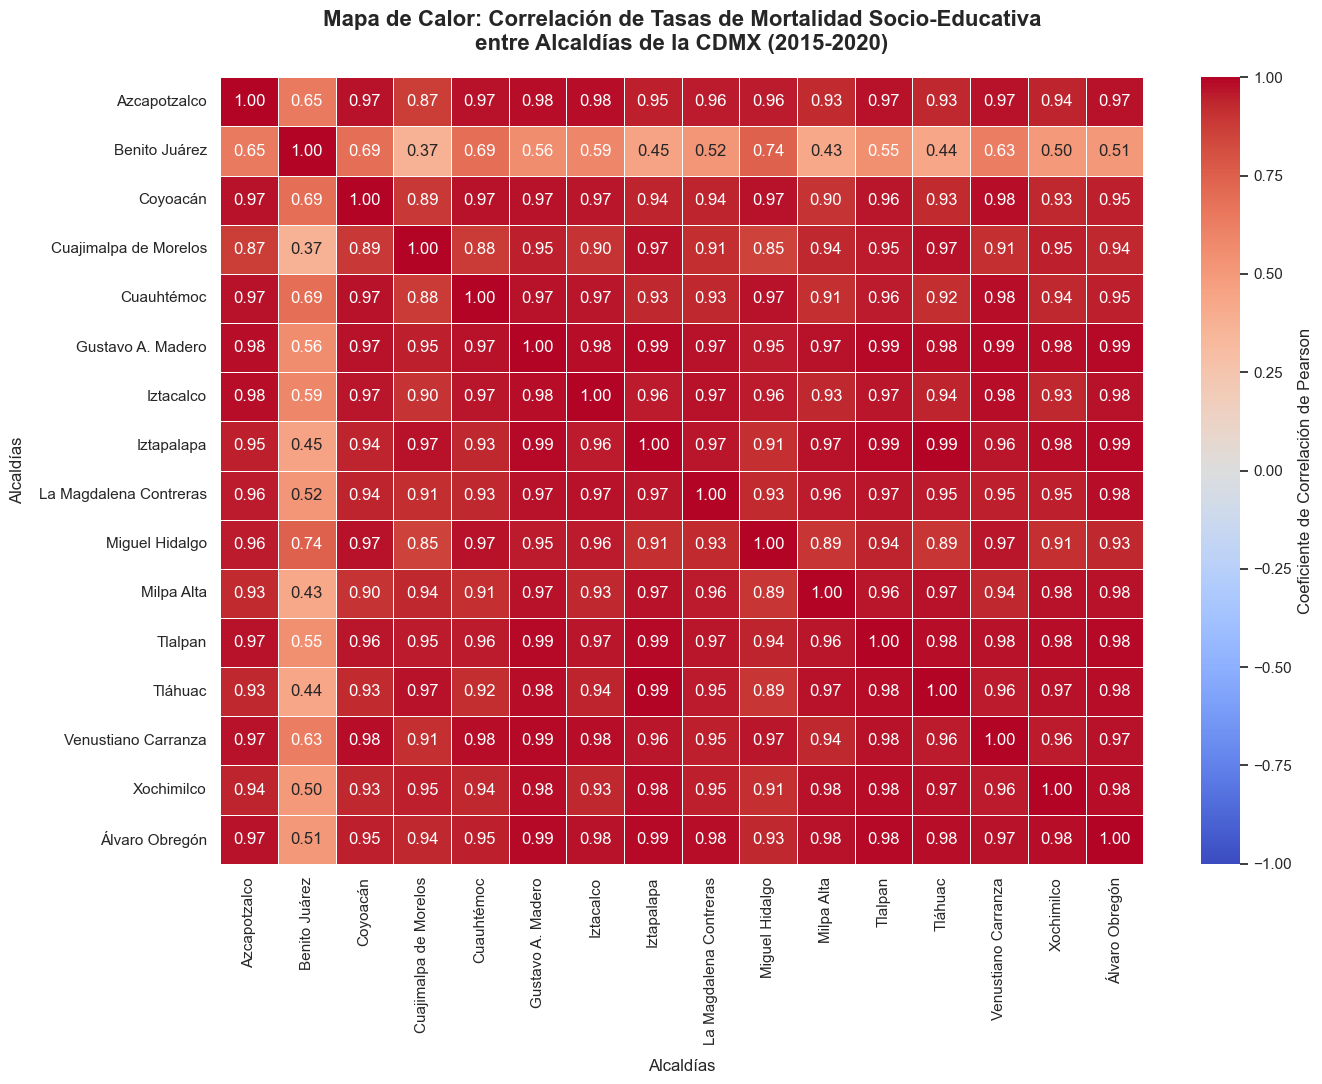

In [19]:


# 1. Aseguramos que los datos estén limpios y agrupados (usando el df_final del paso anterior)
# Necesitamos las columnas: 'año', 'nom_mun', 'escolaridad_limpia', 'tasa_100k'

# 2. Creamos una columna combinada de contexto para las filas (Año + Escolaridad)
df_final['periodo_escolaridad'] = df_final['año'].astype(str) + "_" + df_final['escolaridad_limpia']

# 3. Pivotamos el DataFrame para tener las Alcaldías como columnas
# Filas: Combinaciones de Año_Escolaridad | Columnas: Alcaldías | Valores: Tasas
df_perfiles = df_final.pivot(index='periodo_escolaridad', columns='nom_mun', values='tasa_100k')

# 4. Calculamos la matriz de correlación de Pearson entre las columnas (Alcaldías)
matriz_corr = df_perfiles.corr(method='pearson')

# 5. Graficamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(14, 11))

# Usamos una paleta divergente o secuencial cálida. 'Coolwarm' o 'YlOrRd' funcionan excelente.
# vmin y vmax aseguran que la escala vaya estrictamente del -1 al 1
sns.heatmap(
    matriz_corr, 
    annot=True,          # Muestra el valor numérico de la correlación en cada celda
    fmt=".2f",           # Limita a 2 decimales
    cmap="coolwarm",     # Azul = Correlación baja/negativa, Rojo = Correlación alta
    vmin=-1, 
    vmax=1,
    linewidths=0.5,      # Línea sutil de separación entre celdas
    cbar_kws={"label": "Coeficiente de Correlación de Pearson"}
)

# Personalización de etiquetas y títulos
plt.title('Mapa de Calor: Correlación de Tasas de Mortalidad Socio-Educativa\nentre Alcaldías de la CDMX (2015-2020)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Alcaldías', fontsize=12, labelpad=10)
plt.ylabel('Alcaldías', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('eda/correlacionsocioeducativaAlcadia.png', dpi=300, bbox_inches='tight')
plt.show()

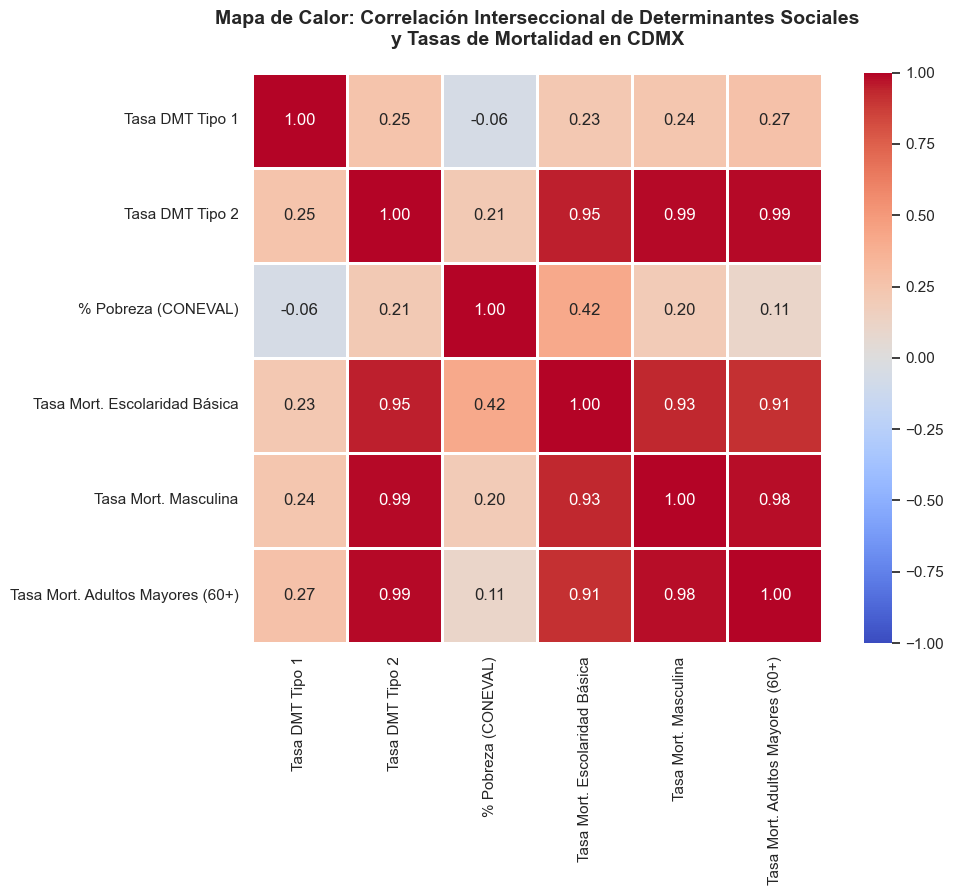

In [20]:


# ==========================================
# 1. PREPARACIÓN BASE (POBLACIÓN TOTAL POR MUNICIPIO Y AÑO)
# ==========================================
inegi_base = inegi[['año', 'mun', 'nom_mun', 'pobtot', 'pobmas', 'pobfem']].copy()
inegi_base = inegi_base.rename(columns={'mun': 'clave_municipio'})
inegi_base = inegi_base[inegi_base['clave_municipio'] != 0] # Quitar total estatal

# ==========================================
# 2. PROCESAMIENTO DE TASAS DESDE DGIS
# ==========================================
# Clonamos dgis para no alterar el original
df_dgis = dgis.copy()

# A) Conteo de Diabetes Tipo 1 (CIE-10: E10) y Tipo 2 (CIE-10: E11)
# Ajusta 'causa_def' si tu columna tiene los códigos completos (ej. E119, E101) usando .str.startswith()
df_dgis['dmt1'] = df_dgis['causa_def'].astype(str).str.startswith('E10').astype(int)
df_dgis['dmt2'] = df_dgis['causa_def'].astype(str).str.startswith('E11').astype(int)

# B) Agrupación de Escolaridad, Sexo y Edad en bloques vulnerables de referencia
# mapeo_escolaridad = {
#     1: 'Sin Escolaridad / Incompleta',
#     2: 'Preescolar',
#     3: 'Primaria',
#     4: 'Primaria',
#     5: 'Secundaria',
#     6: 'Secundaria',
#     7: 'Media Superior (Bachillerato)',
#     8: 'Media Superior (Bachillerato)',
#     9: 'Superior (Licenciatura o más)',
#     10: 'Superior (Licenciatura o más)',
#     # Si tus datos vienen codificados como números (ej. 1, 2, 3), mapea los números aquí:
#     # 1: 'Sin Escolaridad / Incompleta', 2: 'Básica (Primaria/Secundaria)', etc.
# }
# Elegimos los bloques que metodológicamente tienen mayor impacto socioeconómico
df_dgis['esc_basica'] = df_dgis['escolarida'].isin([1, 2,3,4,5,6]).astype(int)
df_dgis['sexo_masc'] = df_dgis['sexo'].isin([1, '1', 'M', 'Hombres']).astype(int)
df_dgis['edad_60ymas'] = (df_dgis['edad'] >= 60).astype(int)

# C) Agrupamos todos los conteos por Año y Municipio
df_conteos = df_dgis.groupby(['año', 'clave_municipio']).agg(
    casos_dmt1=('dmt1', 'sum'),
    casos_dmt2=('dmt2', 'sum'),
    casos_esc_basica=('esc_basica', 'sum'),
    casos_sexo_masc=('sexo_masc', 'sum'),
    casos_edad_60ymas=('edad_60ymas', 'sum')
).reset_index()

# ==========================================
# 3. UNIFICACIÓN Y CÁLCULO DE TASAS (MERGE CON INEGI)
# ==========================================
df_analisis = pd.merge(df_conteos, inegi_base, on=['año', 'clave_municipio'], how='inner')

# Calculamos las tasas específicas por cada 100,000 habitantes
df_analisis['tasa_dmt1'] = (df_analisis['casos_dmt1'] / df_analisis['pobtot']) * 100000
df_analisis['tasa_dmt2'] = (df_analisis['casos_dmt2'] / df_analisis['pobtot']) * 100000
df_analisis['tasa_mortalidad_esc_basica'] = (df_analisis['casos_esc_basica'] / df_analisis['pobtot']) * 100000
df_analisis['tasa_mortalidad_masculina'] = (df_analisis['casos_sexo_masc'] / df_analisis['pobmas']) * 100000
df_analisis['tasa_mortalidad_60ymas'] = (df_analisis['casos_edad_60ymas'] / df_analisis['pobtot']) * 100000

# ==========================================
# 4. INTEGRACIÓN DE POBREZA (CONEVAL)
# ==========================================
coneval_subset = coneval[['año', 'clave_municipio', 'pobreza_porcentaje']].copy()

# Forzar tipos de datos idénticos para evitar fallos en el merge
df_analisis['año'] = df_analisis['año'].astype(int)
df_analisis['clave_municipio'] = df_analisis['clave_municipio'].astype(int)
coneval_subset['año'] = coneval_subset['año'].astype(int)
coneval_subset['clave_municipio'] = coneval_subset['clave_municipio'].astype(int)

# Cruzamos la información socioeconómica
df_master = pd.merge(df_analisis, coneval_subset, on=['año', 'clave_municipio'], how='inner')

# ==========================================
# 5. MATRIZ DE CORRELACIÓN Y MAPA DE CALOR
# ==========================================
columnas_corr = [
    'tasa_dmt1', 'tasa_dmt2', 'pobreza_porcentaje', 
    'tasa_mortalidad_esc_basica', 'tasa_mortalidad_masculina', 'tasa_mortalidad_60ymas'
]

# Calculamos la correlación
matriz_interseccional = df_master[columnas_corr].corr(method='pearson')

# Renombramos las variables en la matriz para que luzcan profesionales en tu reporte
nombres_limpios = {
    'tasa_dmt1': 'Tasa DMT Tipo 1',
    'tasa_dmt2': 'Tasa DMT Tipo 2',
    'pobreza_porcentaje': '% Pobreza (CONEVAL)',
    'tasa_mortalidad_esc_basica': 'Tasa Mort. Escolaridad Básica',
    'tasa_mortalidad_masculina': 'Tasa Mort. Masculina',
    'tasa_mortalidad_60ymas': 'Tasa Mort. Adultos Mayores (60+)'
}
matriz_interseccional = matriz_interseccional.rename(index=nombres_limpios, columns=nombres_limpios)

# Graficamos
plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_interseccional, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.8,
    square=True
)

plt.title('Mapa de Calor: Correlación Interseccional de Determinantes Sociales\ny Tasas de Mortalidad en CDMX', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda/correlacionTasas.png', dpi=300, bbox_inches='tight')
plt.show()

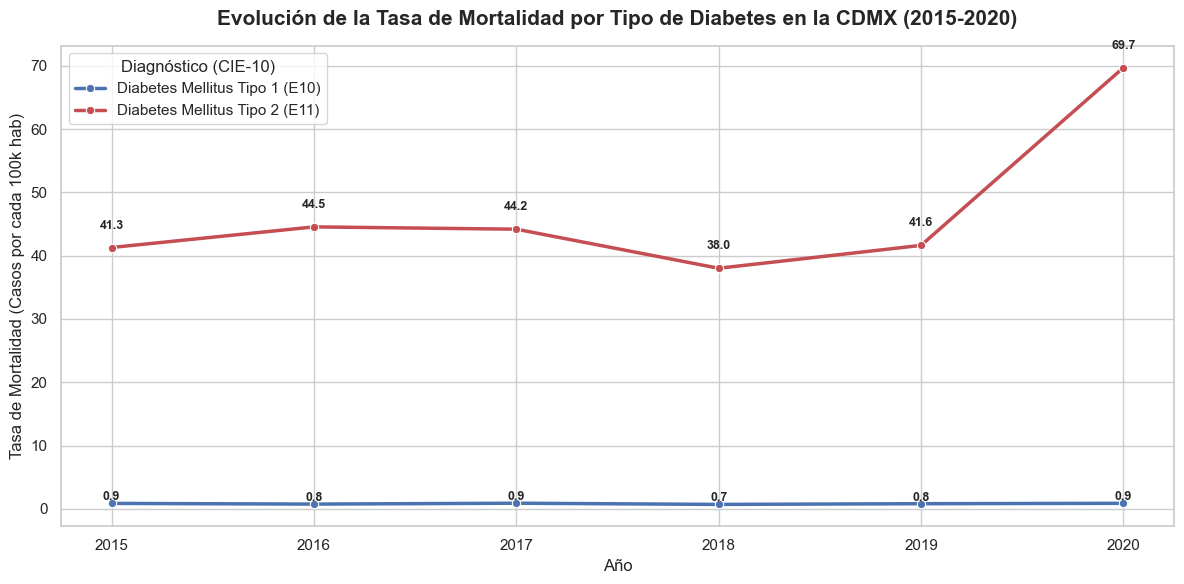

In [21]:

# 1. Identificar los tipos de Diabetes Mellitus (DMT) en DGIS usando códigos CIE-10
df_dgis_dmt = dgis.copy()
df_dgis_dmt['dmt1'] = df_dgis_dmt['causa_def'].astype(str).str.startswith('E10').astype(int)
df_dgis_dmt['dmt2'] = df_dgis_dmt['causa_def'].astype(str).str.startswith('E11').astype(int)

# 2. Agrupar los conteos de casos por año a nivel estatal (CDMX)
df_casos_dmt = df_dgis_dmt.groupby('año').agg(
    DMT_Tipo_1=('dmt1', 'sum'),
    DMT_Tipo_2=('dmt2', 'sum')
).reset_index()

# 3. Obtener la población total de la CDMX por año desde el dataset INEGI
# Agrupamos por año para consolidar todas las alcaldías en el total estatal
df_pob_cdmx = inegi.groupby('año')['pobtot'].sum().reset_index()

# 4. Combinar los conteos con la población total
df_tasas_dmt = pd.merge(df_casos_dmt, df_pob_cdmx, on='año', how='inner')

# 5. Calcular la Tasa de Mortalidad por cada 100,000 habitantes para cada tipo
df_tasas_dmt['tasa_dmt1'] = (df_tasas_dmt['DMT_Tipo_1'] / df_tasas_dmt['pobtot']) * 100000
df_tasas_dmt['tasa_dmt2'] = (df_tasas_dmt['DMT_Tipo_2'] / df_tasas_dmt['pobtot']) * 100000

# 6. Reestructurar el DataFrame (Melt) para facilitar el mapeo de colores con Seaborn
df_grafica = df_tasas_dmt.melt(
    id_vars=['año'], 
    value_vars=['tasa_dmt1', 'tasa_dmt2'],
    var_name='Tipo_Diabetes', 
    value_name='tasa_100k'
)

# Homologamos los nombres para la leyenda de la gráfica
df_grafica['Tipo_Diabetes'] = df_grafica['Tipo_Diabetes'].replace({
    'tasa_dmt1': 'Diabetes Mellitus Tipo 1 (E10)',
    'tasa_dmt2': 'Diabetes Mellitus Tipo 2 (E11)'
})

# Filtrar para el periodo del estudio (2015-2020)
df_grafica = df_grafica[(df_grafica['año'] >= 2015) & (df_grafica['año'] <= 2020)].sort_values('año')

# ==========================================
# 7. DISEÑO DE LA GRÁFICA
# ==========================================
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Dibujamos las líneas con marcadores y una paleta de colores contrastante
sns.lineplot(
    data=df_grafica, 
    x='año', 
    y='tasa_100k', 
    hue='Tipo_Diabetes', 
    marker='o', 
    linewidth=2.5,
    palette={'Diabetes Mellitus Tipo 1 (E10)': '#4c72b0', 'Diabetes Mellitus Tipo 2 (E11)': '#c44e52'}
)

# Personalización de etiquetas y formato
plt.title('Evolución de la Tasa de Mortalidad por Tipo de Diabetes en la CDMX (2015-2020)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Tasa de Mortalidad (Casos por cada 100k hab)', fontsize=12)
plt.xticks(sorted(df_grafica['año'].unique()))

# Agregar etiquetas de datos sobre los puntos para hacer la gráfica autodocumentada
for index, fila in df_grafica.iterrows():
    # Pequeño ajuste en la posición vertical para que los números no se encimen
    offset = 3 if 'Tipo 2' in fila['Tipo_Diabetes'] else 0.5
    plt.text(
        fila['año'], 
        fila['tasa_100k'] + offset, 
        f"{fila['tasa_100k']:.1f}", 
        ha='center', 
        fontsize=9, 
        fontweight='semibold'
    )

plt.legend(title='Diagnóstico (CIE-10)', loc='upper left')
plt.tight_layout()
plt.savefig('eda/evolucionpordmt.png', dpi=300, bbox_inches='tight')
plt.show()

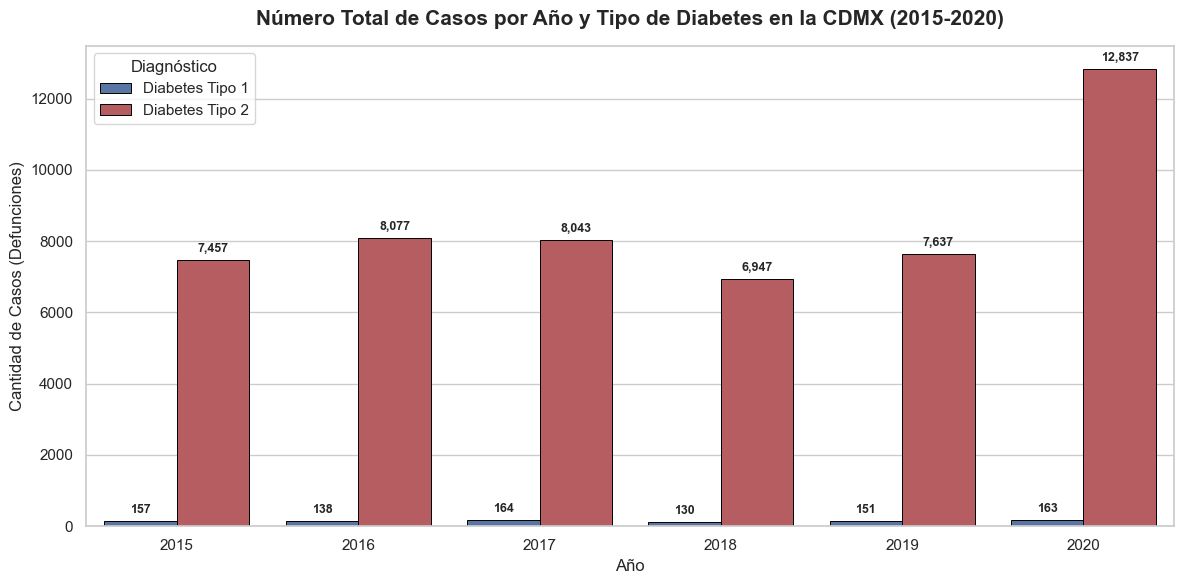

In [22]:


# 1. Filtrar los años de tu periodo de estudio (2015-2020)
df_filtrado = dgis[(dgis['año'] >= 2015) & (dgis['año'] <= 2020)].copy()

# 2. Contar el número de casos agrupando por año y tipo de diabetes (dmt)
df_conteos = df_filtrado.groupby(['año', 'dmt']).size().reset_index(name='numero_casos')

# 3. Mapear los números 1 y 2 a nombres claros para que la leyenda de la gráfica se entienda solita
df_conteos['Tipo de Diabetes'] = df_conteos['dmt'].replace({
    1: 'Diabetes Tipo 1',
    2: 'Diabetes Tipo 2',
    '1': 'Diabetes Tipo 1', # Por si acaso tus números están guardados como texto
    '2': 'Diabetes Tipo 2'
})

# ==========================================
# 4. DISEÑO DE LA GRÁFICA
# ==========================================
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Graficamos las barras usando 'hue' para separar el tipo de diabetes
ax = sns.barplot(
    data=df_conteos,
    x='año',
    y='numero_casos',
    hue='Tipo de Diabetes',
    palette={'Diabetes Tipo 1': '#4c72b0', 'Diabetes Tipo 2': '#c44e52'},
    edgecolor='black',
    linewidth=0.7
)

# Personalización de títulos y ejes
plt.title('Número Total de Casos por Año y Tipo de Diabetes en la CDMX (2015-2020)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Casos (Defunciones)', fontsize=12)

# Colocar el número exacto sobre cada barra para tu reporte
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{int(p.get_height()):,}", # Agrega comas para separar miles (ej. 11,250)
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            xytext=(0, 8),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

plt.legend(title='Diagnóstico', loc='upper left')
plt.tight_layout()
plt.savefig('eda/casosportipodmt.png', dpi=300, bbox_inches='tight')

plt.show()

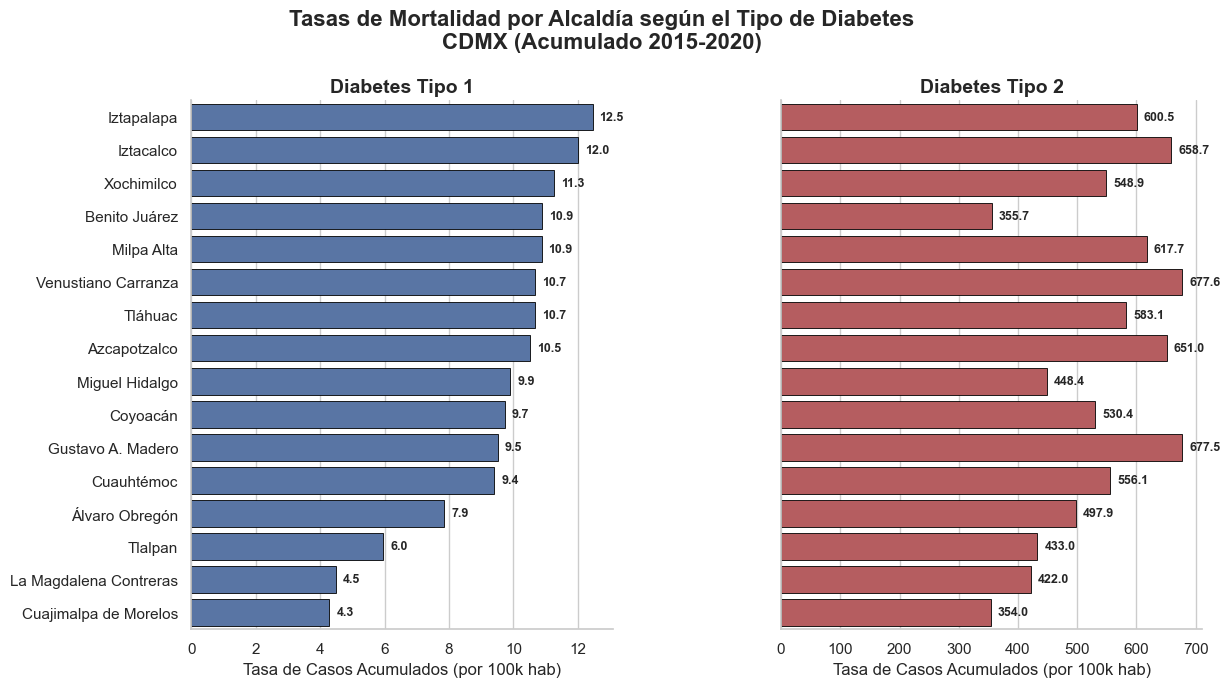

In [23]:


# 1. Filtrar los años de estudio (2015-2020) y quitar registros sin alcaldía válida
df_dgis_filtrado = dgis[(dgis['año'] >= 2015) & (dgis['año'] <= 2020)].copy()

# 2. Contar casos acumulados agrupando por Alcaldía (clave_municipio) y Tipo de Diabetes (dmt)
df_casos_alc = (
    df_dgis_filtrado
    .groupby(['clave_municipio', 'dmt'])
    .size()
    .reset_index(name='total_casos')
)

# 3. Obtener la población promedio de cada alcaldía durante el periodo de estudio desde INEGI
# (Usamos el promedio de población 2015-2020 para estandarizar el acumulado de casos)
df_pob_alc = (
    inegi[(inegi['año'] >= 2015) & (inegi['año'] <= 2020) & (inegi['mun'] != 0)]
    .groupby(['mun', 'nom_mun'])['pobtot']
    .mean()
    .reset_index(name='pob_promedio')
    .rename(columns={'mun': 'clave_municipio'})
)

# 4. Combinar los decesos con los datos de población
df_tasas_alc = pd.merge(df_casos_alc, df_pob_alc, on='clave_municipio', how='inner')

# 5. Calcular la Tasa de Casos Acumulados por cada 100,000 habitantes
df_tasas_alc['tasa_100k'] = (df_tasas_alc['total_casos'] / df_tasas_alc['pob_promedio']) * 100000
#df_tasas_alc['tasa_100k'] = df_tasas_alc['total_casos']

# Mapear nombres claros para los paneles de la gráfica
df_tasas_alc['Tipo de Diabetes'] = df_tasas_alc['dmt'].replace({
    1: 'Diabetes Tipo 1', 1.0: 'Diabetes Tipo 1', '1': 'Diabetes Tipo 1',
    2: 'Diabetes Tipo 2', 2.0: 'Diabetes Tipo 2', '2': 'Diabetes Tipo 2'
})

# ==========================================
# 6. DISEÑO DE LA GRÁFICA FACETADA
# ==========================================
# Creamos una cuadrícula de 1 fila x 2 columnas (un panel para cada tipo de diabetes)
# sharex=False es vital aquí porque la escala de la Tipo 2 es muchísimo más grande
g = sns.FacetGrid(
    df_tasas_alc, 
    col="Tipo de Diabetes", 
    col_order=['Diabetes Tipo 1', 'Diabetes Tipo 2'],
    height=7, 
    aspect=0.9, 
    sharex=False
)

# Definimos una función interna para ordenar las barras de mayor a menor tasa en cada panel
def draw_bars(data, **kwargs):
    # Ordenar los datos locales de este panel de mayor a menor tasa
    data_sorted = data.sort_values('tasa_100k', ascending=False)
    
    # Asignar color dependiendo del tipo de diabetes
    color_panel = '#4c72b0' if 'Tipo 1' in data['Tipo_Diabetes' if 'Tipo_Diabetes' in data.columns else 'Tipo de Diabetes'].iloc[0] else '#c44e52'
    
    ax = sns.barplot(
        data=data_sorted, 
        y='nom_mun', 
        x='tasa_100k', 
        color=color_panel,
        edgecolor='black',
        linewidth=0.6
    )
    
    # Añadir etiquetas con el valor numérico al final de cada barra para precisión del reporte
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(
                f"{width:.1f}",
                (width, p.get_y() + p.get_height() / 2.),
                xytext=(5, 0),
                textcoords='offset points',
                ha='left', 
                va='center', 
                fontsize=9,
                fontweight='semibold'
            )

# Mapeamos la función a la cuadrícula
g.map_dataframe(draw_bars)

# Personalización final de títulos y ejes
g.set_titles(col_template="{col_name}", size=14, weight='bold')
g.set_axis_labels("Tasa de Casos Acumulados (por 100k hab)", "")
g.fig.subplots_adjust(top=0.85, wspace=0.4)
g.fig.suptitle('Tasas de Mortalidad por Alcaldía según el Tipo de Diabetes\nCDMX (Acumulado 2015-2020)', 
               fontsize=16, fontweight='bold')

plt.show()

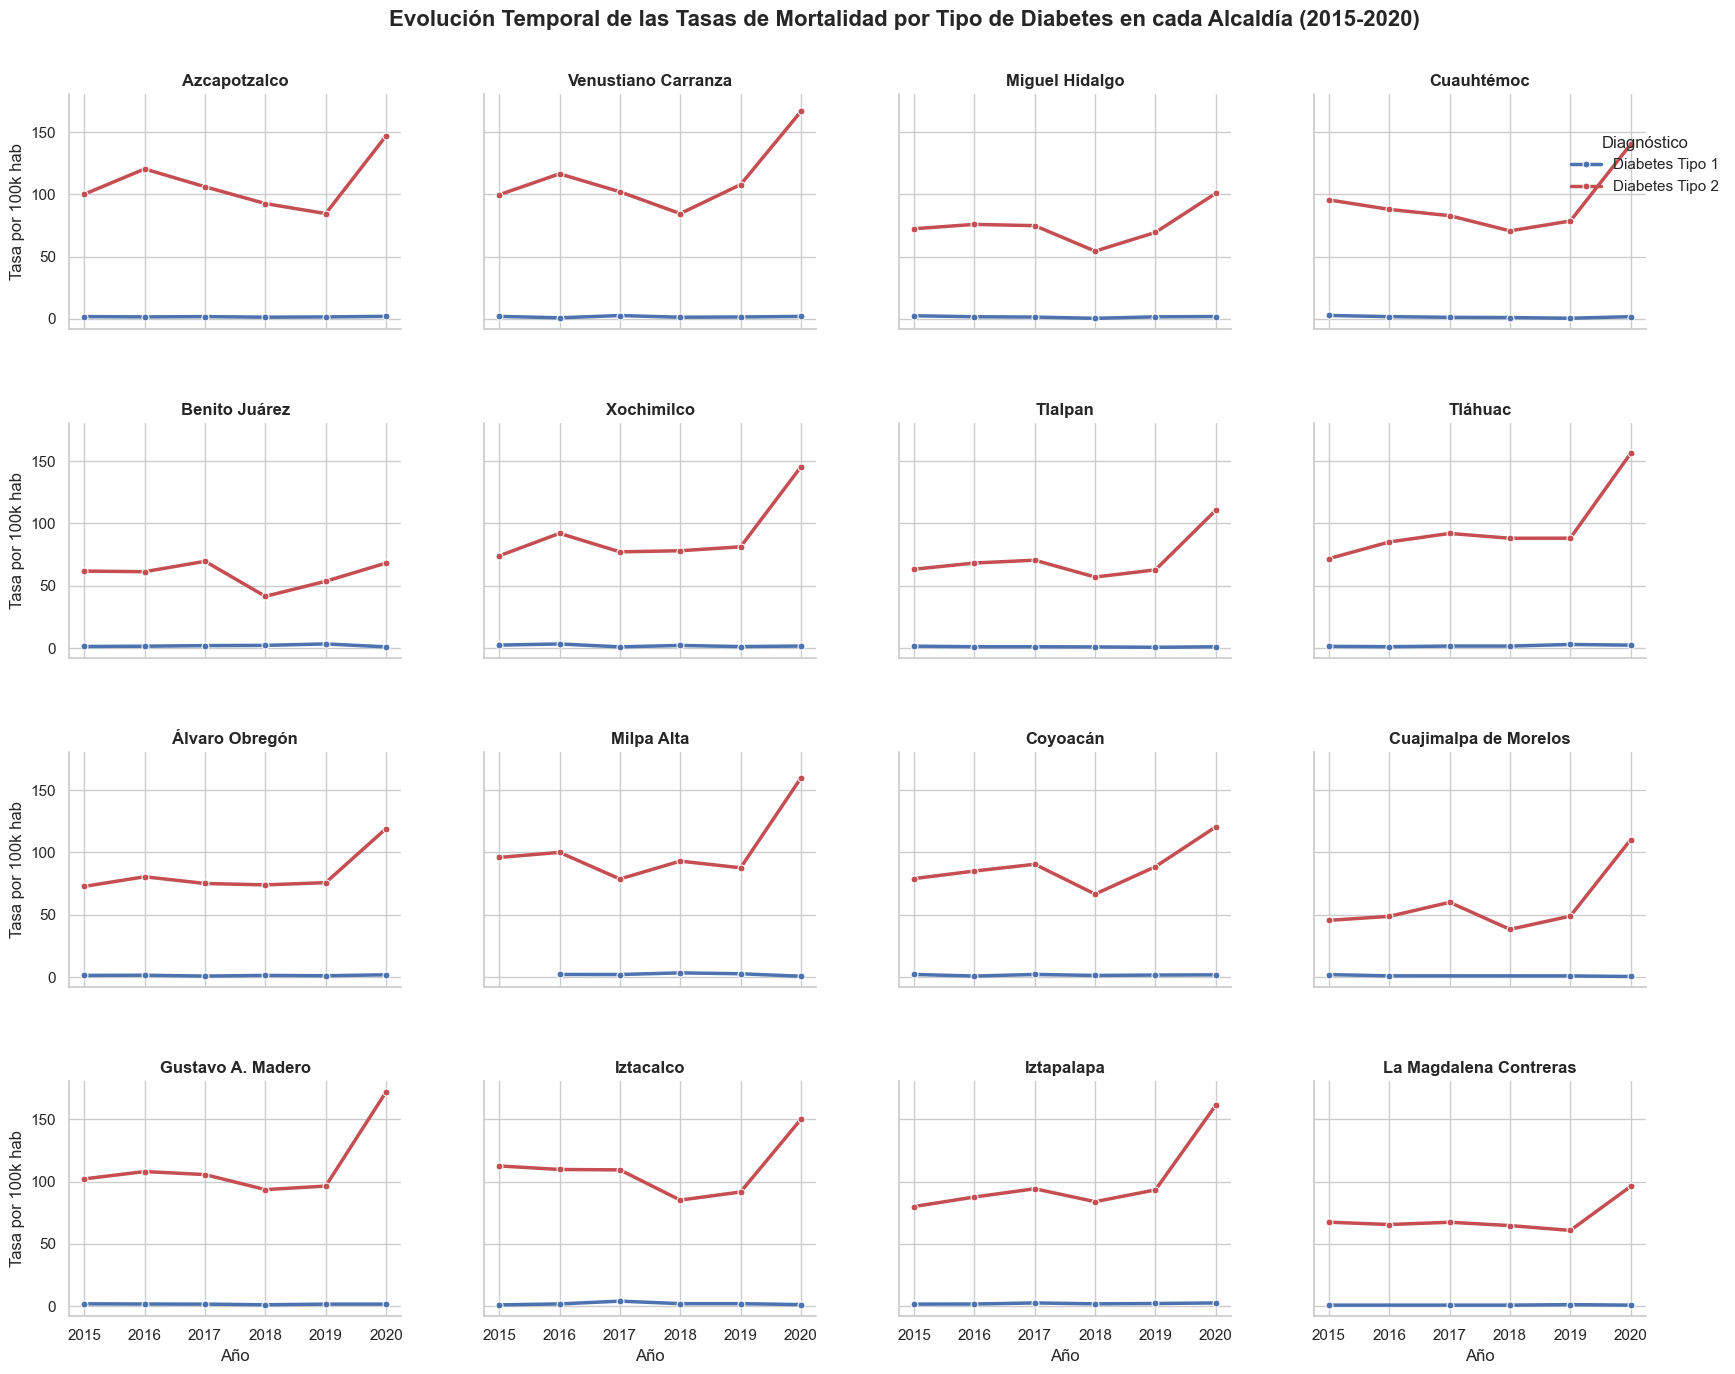

In [24]:


# 1. Filtrar el periodo de estudio (2015-2020) en DGIS
df_dgis_filtrado = dgis[(dgis['año'] >= 2015) & (dgis['año'] <= 2020)].copy()

# 2. Contar casos agrupando por Año, Alcaldía (clave_municipio) y Tipo de Diabetes (dmt)
df_casos_anual = (
    df_dgis_filtrado
    .groupby(['año', 'clave_municipio', 'dmt'])
    .size()
    .reset_index(name='total_casos')
)

# 3. Preparar la población anual por alcaldía desde INEGI
# Filtramos para quitar el total estatal (clave 0)
df_pob_anual = inegi[(inegi['año'] >= 2015) & (inegi['año'] <= 2020) & (inegi['mun'] != 0)].copy()
df_pob_anual = df_pob_anual.rename(columns={'mun': 'clave_municipio'})

# 4. Combinar decesos con población para el cálculo exacto por año y territorio
df_tasas_anual = pd.merge(df_casos_anual, df_pob_anual[['año', 'clave_municipio', 'nom_mun', 'pobtot']], 
                          on=['año', 'clave_municipio'], how='inner')

# 5. Calcular la Tasa de Casos Anual por cada 100,000 habitantes
df_tasas_anual['tasa_100k'] = (df_tasas_anual['total_casos'] / df_tasas_anual['pobtot']) * 100000

# Mapear nombres claros para la leyenda
df_tasas_anual['Tipo de Diabetes'] = df_tasas_anual['dmt'].replace({
    1: 'Diabetes Tipo 1', 1.0: 'Diabetes Tipo 1', '1': 'Diabetes Tipo 1',
    2: 'Diabetes Tipo 2', 2.0: 'Diabetes Tipo 2', '2': 'Diabetes Tipo 2'
})

# Ordenar cronológicamente para que las líneas se dibujen bien
df_tasas_anual = df_tasas_anual.sort_values(by='año')
df_tasaDiabetes = df_tasas_anual 
# ==========================================
# 6. DISEÑO DE LA CUADRÍCULA POR ALCALDÍA (4x4)
# ==========================================
# Usamos col_wrap=4 para acomodar las 16 alcaldías de forma simétrica
# sharey=False es clave aquí porque si una alcaldía tiene tasas muy bajas (ej. Benito Juárez),
# el comportamiento de sus líneas no se verá aplastado por el de alcaldías con tasas altas (ej. Iztapalapa)
g = sns.FacetGrid(
    df_tasas_anual, 
    col="nom_mun", 
    hue="Tipo de Diabetes", 
    col_wrap=4, 
    height=3.5, 
    aspect=1.2,
    palette={'Diabetes Tipo 1': '#4c72b0', 'Diabetes Tipo 2': '#c44e52'}
)

# Dibujar las líneas y los marcadores en cada panel
g.map(sns.lineplot, "año", "tasa_100k", marker="o", linewidth=2.5, markersize=5)

# Personalización estética de la cuadrícula
g.set_titles(col_template="{col_name}", size=12, weight='bold')
g.set_axis_labels("Año", "Tasa por 100k hab")
g.set(xticks=sorted(df_tasas_anual['año'].unique()))

# Agregar leyenda global para evitar repetir el cuadro en cada mini gráfica
g.add_legend(title="Diagnóstico", loc='upper right', bbox_to_anchor=(0.95, 0.9))

# Ajustar márgenes para que el título principal no se encima con las gráficas superiores
g.fig.subplots_adjust(top=0.92, hspace=0.4, wspace=0.25)
g.fig.suptitle('Evolución Temporal de las Tasas de Mortalidad por Tipo de Diabetes en cada Alcaldía (2015-2020)', 
               fontsize=16, fontweight='bold')

plt.show()

Número de registros listos para graficar: 51901


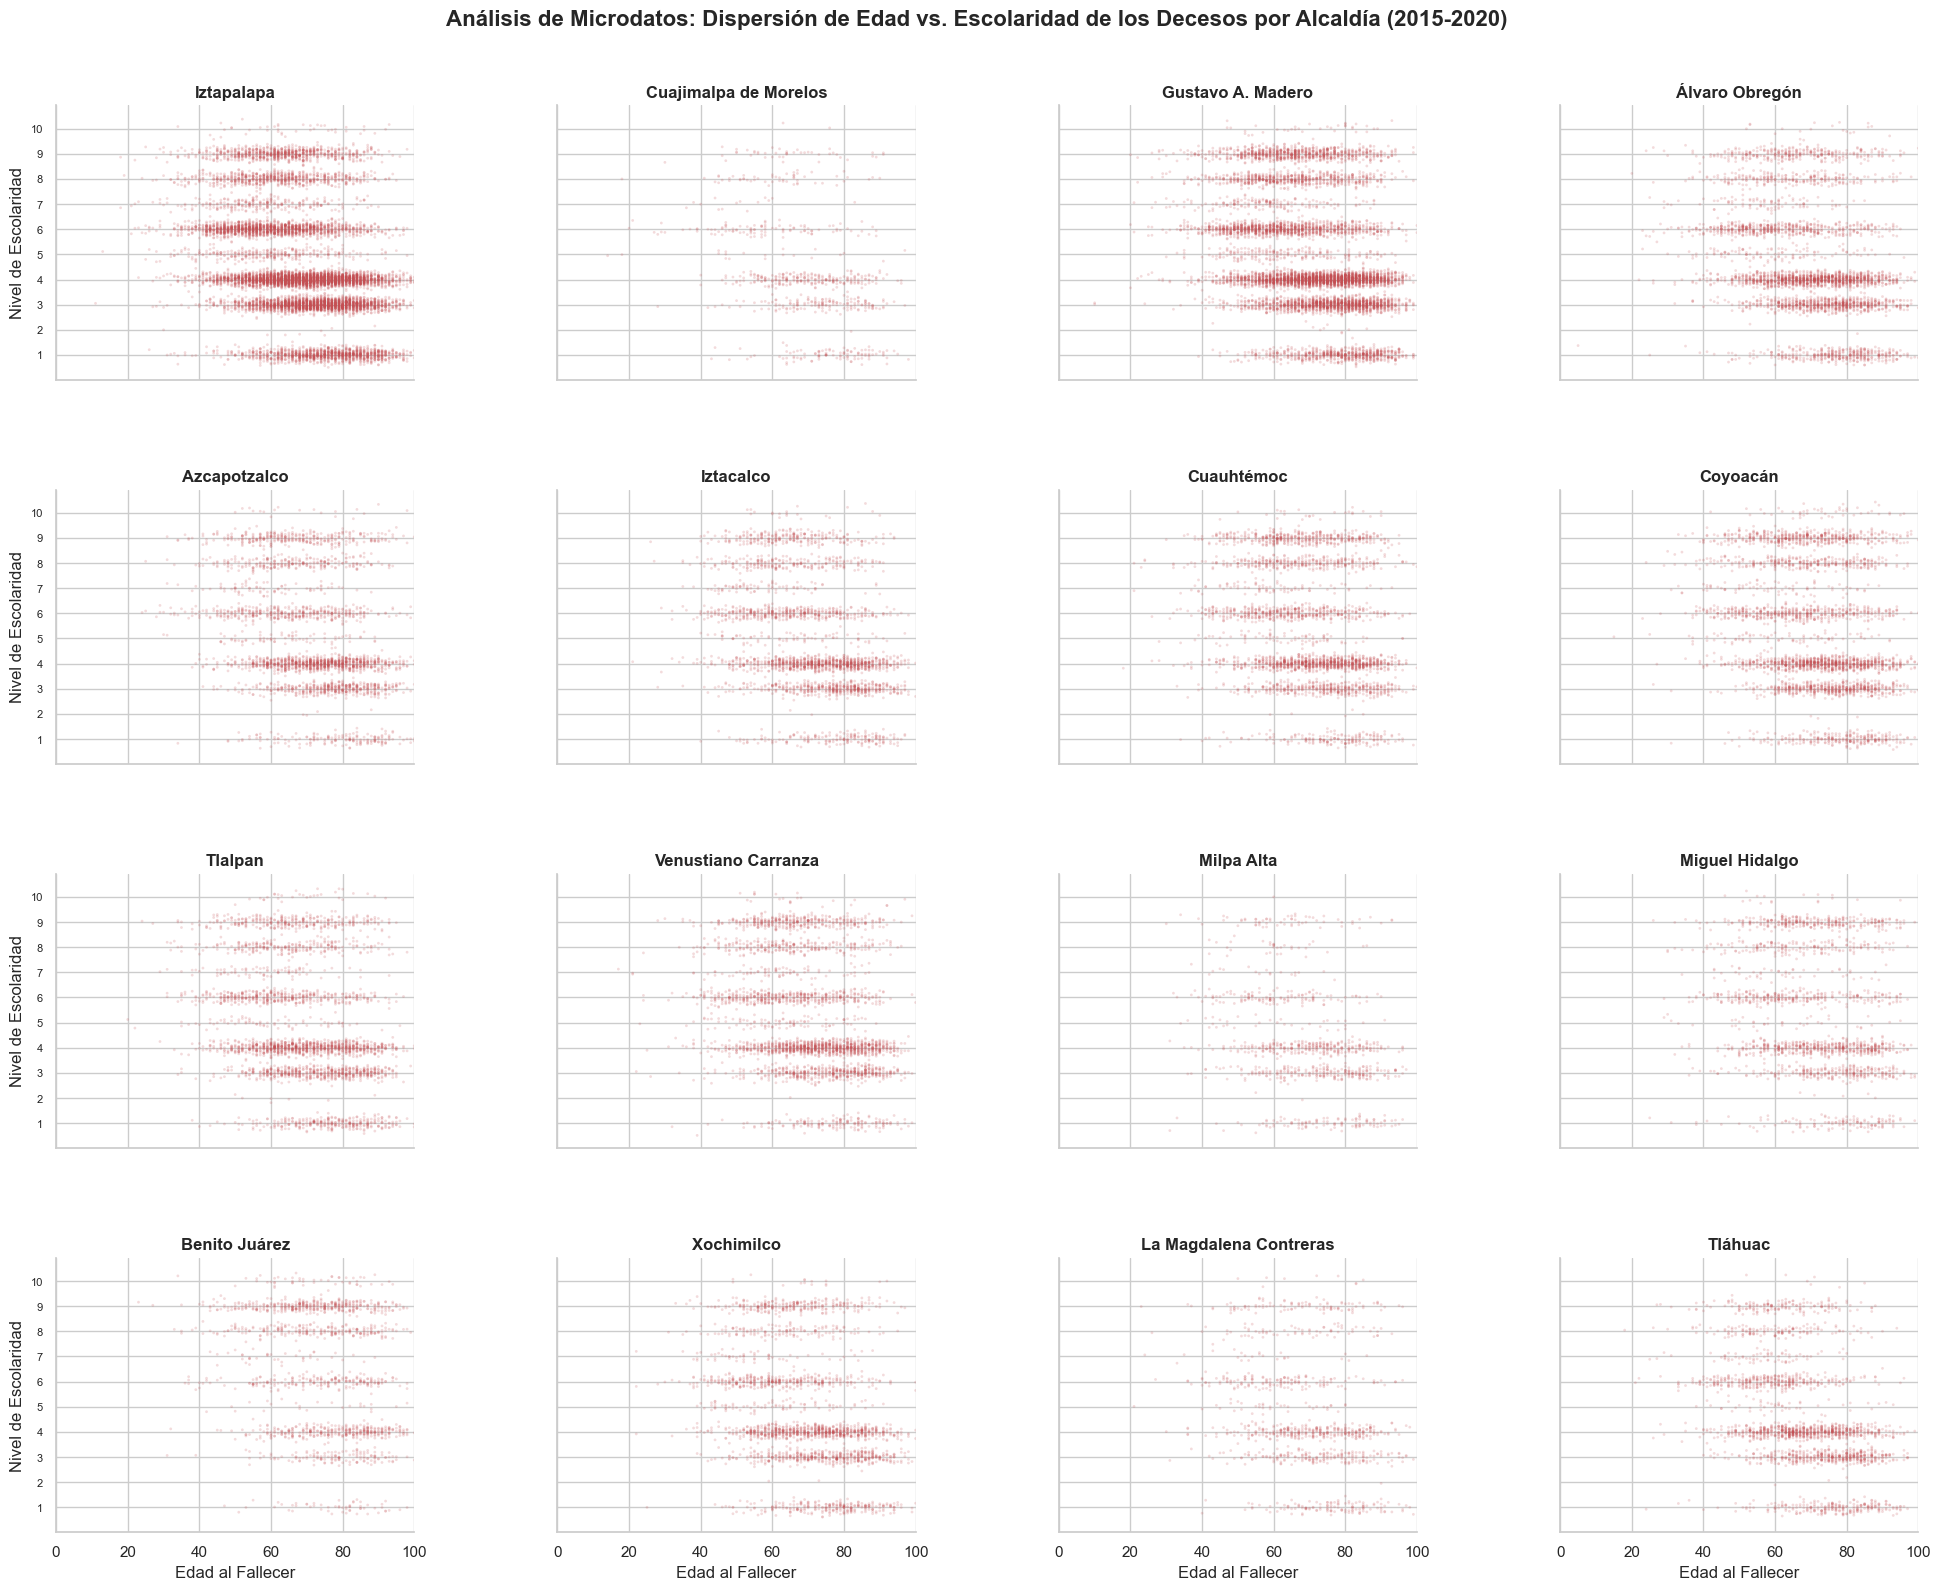

In [25]:


# 1. Crear copia y limpiar registros sin datos clave
df_dgis_scatter = dgis[(dgis['año'] >= 2015) & (dgis['año'] <= 2020)].copy()
df_dgis_scatter = df_dgis_scatter.dropna(subset=['edad', 'escolarida', 'clave_municipio'])

# 2. Homologar la lista de escolaridades (Asegúrate de que coincidan con tus datos reales)
orden_escolaridad = [
    1,2,3,4,5,6,7,8,9,10
]

# Si el filtro es muy estricto y te deja vacío el df, puedes comentar temporalmente la siguiente línea:
df_dgis_scatter = df_dgis_scatter[df_dgis_scatter['escolarida'].isin(orden_escolaridad)]

# Convertir a códigos numéricos para graficar
df_dgis_scatter['escolaridad_num'] = df_dgis_scatter['escolarida'].astype(pd.CategoricalDtype(categories=orden_escolaridad, ordered=True)).cat.codes

# 3. Preparar el DataFrame de nombres de INEGI y FORZAR TIPO ENTERO
df_pob_nombres = inegi[['mun', 'nom_mun']].drop_duplicates().copy()
df_pob_nombres = df_pob_nombres.rename(columns={'mun': 'clave_municipio'})

# ¡AQUÍ ESTÁ EL TRUCO! Forzamos a que ambas columnas de cruce sean estrictamente enteros numéricos
df_dgis_scatter['clave_municipio'] = pd.to_numeric(df_dgis_scatter['clave_municipio'], errors='coerce')
df_pob_nombres['clave_municipio'] = pd.to_numeric(df_pob_nombres['clave_municipio'], errors='coerce')

# Eliminamos posibles NaN creados por errores de conversión
df_dgis_scatter = df_dgis_scatter.dropna(subset=['clave_municipio'])

# 4. Realizar el merge corregido
df_dgis_scatter = pd.merge(df_dgis_scatter, df_pob_nombres, on='clave_municipio', how='inner')

# CONTROL DE CALIDAD: Verificamos si el DataFrame sobrevivió al cruce
print(f"Número de registros listos para graficar: {len(df_dgis_scatter)}")
if len(df_dgis_scatter) == 0:
    print("⚠️ ALERTA: El DataFrame sigue quedando vacío. Revisa si dgis['escolarida'] tiene los textos exactos de la lista.")

# Si el contador de arriba arroja más de 0 registros, el FacetGrid de abajo ya no fallará:
# [Continúa aquí con el paso 5 del FacetGrid...]
# ==========================================
# 5. DISEÑO DE LA CUADRÍCULA SCATTER (4x4)
# ==========================================
g = sns.FacetGrid(
    df_dgis_scatter, 
    col="nom_mun", 
    col_wrap=4, 
    height=4, 
    aspect=1.2
)

# Definimos una función personalizada para aplicar Scatter con Jittering manual
def custom_scatter(data, **kwargs):
    # Añadimos un pequeño ruido aleatorio (Jitter) solo al eje Y (escolaridad) para dispersar los puntos empalmados
    jitter = np.random.normal(0, 0.15, size=len(data))
    y_con_jitter = data['escolaridad_num'] + jitter
    
    plt.scatter(
        data['edad'], 
        y_con_jitter, 
        alpha=0.2,       # Transparencia clave para ver densidad de puntos
        s=4,             # Tamaño pequeño del punto
        color='#c44e52', # Color rojizo epidemiológico
        edgecolors='none'
    )

# Mapeamos la función a la cuadrícula
g.map_dataframe(custom_scatter)

# 6. Personalización de los ejes y etiquetas de escolaridad
g.set_titles(col_template="{col_name}", size=12, weight='bold')
g.set_axis_labels("Edad al Fallecer", "Nivel de Escolaridad")

# Reemplazamos los números del eje Y (0-9) con los textos reales de escolaridad en todos los paneles necesarios
for ax in g.axes.flat:
    ax.set_yticks(range(len(orden_escolaridad)))
    ax.set_yticklabels(orden_escolaridad, fontsize=8)
    ax.set_xlim(0, 100) # Centramos la atención en el ciclo de vida de 0 a 100 años

g.fig.subplots_adjust(top=0.92, hspace=0.4, wspace=0.4)
g.fig.suptitle('Análisis de Microdatos: Dispersión de Edad vs. Escolaridad de los Decesos por Alcaldía (2015-2020)', 
               fontsize=16, fontweight='bold')

plt.show()

In [26]:
coneval.columns

Index(['año', 'clave_municipio', 'municipio', 'pobreza_porcentaje',
       'pobreza_poblacion', 'pobreza_extrema_porcentaje',
       'pobreza_extrema_poblacion', 'pobreza_moderada_porcentaje',
       'pobreza_moderada_poblacion'],
      dtype='object')

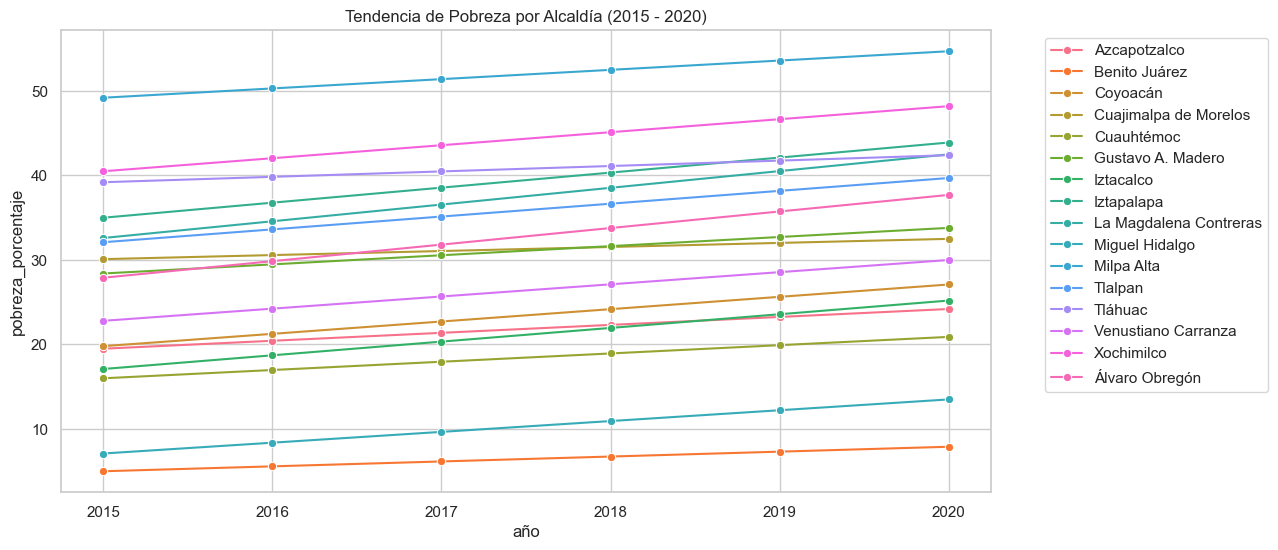

In [27]:
coneval2 = coneval[coneval['año']>=2015]
plt.figure(figsize=(12,6))
sns.lineplot(data=coneval2[coneval2['clave_municipio'] != 0], # Excluimos el Total CDMX para no sesgar
             x='año', y='pobreza_porcentaje', hue='municipio', marker='o')
plt.title('Tendencia de Pobreza por Alcaldía (2015 - 2020)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.savefig('graficas/pobrezaAnual.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
ultimo = coneval[coneval["año"] == 2020]
ultimo[["municipio","pobreza_porcentaje"]].sort_values(by="pobreza_porcentaje")

,municipio,pobreza_porcentaje
21,Benito Juárez,7.9
109,Miguel Hidalgo,13.5
54,Cuauhtémoc,20.9
10,Azcapotzalco,24.2
76,Iztacalco,25.2
32,Coyoacán,27.1
153,Venustiano Carranza,30.0
43,Cuajimalpa de Morelos,32.5
65,Gustavo A. Madero,33.8
175,Álvaro Obregón,37.7


In [29]:
#df_tasasMortalidad
#df_tasasSexo
#df_tasaDiabetes
df_tasaEscolaridad

,año,clave_municipio,escolaridad_limpia,conteo_casos,nom_mun,pobtot,tasa_100k,periodo_escolaridad
0,2015,2,Media Superior (Bachillerato),65,Azcapotzalco,423458.0,15.349810,2015_Media Superior (Bachillerato)
60,2015,13,Sin Escolaridad / Incompleta,43,Xochimilco,428592.0,10.032852,2015_Sin Escolaridad / Incompleta
59,2015,13,Secundaria,54,Xochimilco,428592.0,12.599395,2015_Secundaria
58,2015,13,Primaria,159,Xochimilco,428592.0,37.098219,2015_Primaria
57,2015,13,Media Superior (Bachillerato),30,Xochimilco,428592.0,6.999664,2015_Media Superior (Bachillerato)
...,...,...,...,...,...,...,...,...
448,2020,6,Sin Escolaridad / Incompleta,43,Iztacalco,404695.0,10.625286,2020_Sin Escolaridad / Incompleta
447,2020,6,Secundaria,119,Iztacalco,404695.0,29.404860,2020_Secundaria
446,2020,6,Primaria,289,Iztacalco,404695.0,71.411804,2020_Primaria
443,2020,5,Sin Escolaridad / Incompleta,161,Gustavo A. Madero,1173351.0,13.721384,2020_Sin Escolaridad / Incompleta


In [30]:
df_tasaDiabetes

,año,clave_municipio,dmt,total_casos,nom_mun,pobtot,tasa_100k,Tipo de Diabetes
0,2015,2,1,8,Azcapotzalco,423458.0,1.889207,Diabetes Tipo 1
30,2015,17,2,436,Venustiano Carranza,437341.0,99.693374,Diabetes Tipo 2
29,2015,17,1,9,Venustiano Carranza,437341.0,2.057891,Diabetes Tipo 1
28,2015,16,2,285,Miguel Hidalgo,393680.0,72.393822,Diabetes Tipo 2
27,2015,16,1,10,Miguel Hidalgo,393680.0,2.540134,Diabetes Tipo 1
...,...,...,...,...,...,...,...,...
157,2020,2,2,635,Azcapotzalco,432205.0,146.921021,Diabetes Tipo 2
156,2020,2,1,9,Azcapotzalco,432205.0,2.082345,Diabetes Tipo 1
186,2020,17,1,9,Venustiano Carranza,443704.0,2.028379,Diabetes Tipo 1
170,2020,9,1,1,Milpa Alta,152685.0,0.654943,Diabetes Tipo 1


In [31]:
df_tasasMortalidad.colums

AttributeError: 'DataFrame' object has no attribute 'colums'

In [ ]:
df_tasasSexo.colums

In [ ]:
df_tasaDiabetes.colums

In [ ]:
#df_tasasMortalidad.to_csv
df_tasasMortalidad.to_csv("df_tasasMortalidad.csv", index=False, encoding="utf-8")
df_tasasSexo.to_csv("df_tasasSexo.csv", index=False, encoding="utf-8")
df_tasaDiabetes.to_csv("df_tasaDiabetes.csv", index=False, encoding="utf-8")
#df_tasasSexo
#df_tasaDiabetes